# TFG — Predicción de lesiones en corredores de resistencia
## Un enfoque basado en el análisis de la carga de entrenamiento

**Grado en Business Intelligence**  
**Curso 2025–2026**

---

### Estructura del notebook

| Bloque | Contenido |
|--------|-----------|
| 1 | Carga de datos y análisis exploratorio |
| 2 | Ingeniería de variables |
| 3 | Preparación para modelado |
| 4 | Modelos predictivos |
| 5 | Evaluación y comparación |

---

---
## Bloque 1 — Carga de datos y análisis exploratorio

En este bloque cargamos los dos datasets (diario y semanal), verificamos su estructura,
analizamos la variable objetivo `injury` y exploramos las principales variables de entrenamiento.

**Hallazgos clave:**
- Desbalanceo severo de clases (~1.3% de positivos)
- No se han encontrado valores faltantes en ninguno de los dos datasets
- Las variables de carga subjetiva son más diferenciadoras que el volumen puro

In [1]:
# ── Imports y configuración global ──────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

#Con este codigo establezco el estilo de los graficos que generaré durante el trabajo 
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2196F3', '#F44336']

# Ruta automática a la carpeta del notebook
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
print("Directorio de trabajo:", BASE_DIR)

Directorio de trabajo: c:\Users\Ignac\OneDrive - Fundación Universitaria San Pablo CEU\Documentos\CURSO 2025-2026\TFG\Codigo tfg\TFG_Prediccion_lesiones_runnig


In [2]:
# Carga de datos

# Definición de los paths 
PATH_DAILY  = os.path.join(BASE_DIR, "timeseries (daily).csv")
PATH_WEEKLY = os.path.join(BASE_DIR, "timeseries (weekly).csv")

# Carga de los dataframes
df_daily  = pd.read_csv(PATH_DAILY)
df_weekly = pd.read_csv(PATH_WEEKLY)

#Ordenar los datos y cambiar el indice para que esté acorde con el nuevo orden
df_daily  = df_daily.sort_values(['Athlete ID', 'Date']).reset_index(drop=True)
df_weekly = df_weekly.sort_values(['Athlete ID', 'Date']).reset_index(drop=True)

# Crear una pequeña tabla con datos importantes del análisis exploratorio de los datos
print("-" * 55)
print("RESUMEN DE LOS DATASETS")
print("-" * 55)
print(f"  Daily  — filas: {len(df_daily):,}  |  columnas: {df_daily.shape[1]}")
print(f"  Weekly — filas: {len(df_weekly):,}  |  columnas: {df_weekly.shape[1]}")
print(f"  Atletas unicos (daily):  {df_daily['Athlete ID'].nunique()}")
print(f"  Atletas unicos (weekly): {df_weekly['Athlete ID'].nunique()}")
print(f"  Rango temporal: {df_daily['Date'].min()} - {df_daily['Date'].max()}")
print(f"  Valores faltantes — daily:  {df_daily.isna().sum().sum()}")
print(f"  Valores faltantes — weekly: {df_weekly.isna().sum().sum()}")

-------------------------------------------------------
RESUMEN DE LOS DATASETS
-------------------------------------------------------
  Daily  — filas: 42,766  |  columnas: 73
  Weekly — filas: 42,798  |  columnas: 72
  Atletas unicos (daily):  74
  Atletas unicos (weekly): 74
  Rango temporal: 0 - 2673
  Valores faltantes — daily:  0
  Valores faltantes — weekly: 0


### 1.1 Variable objetivo — desbalanceo de clases

[Daily]  injury=0: 42,183  |  injury=1: 583  |  Tasa: 1.36%  |  Ratio: 1:72
[Weekly]  injury=0: 42,223  |  injury=1: 575  |  Tasa: 1.34%  |  Ratio: 1:73


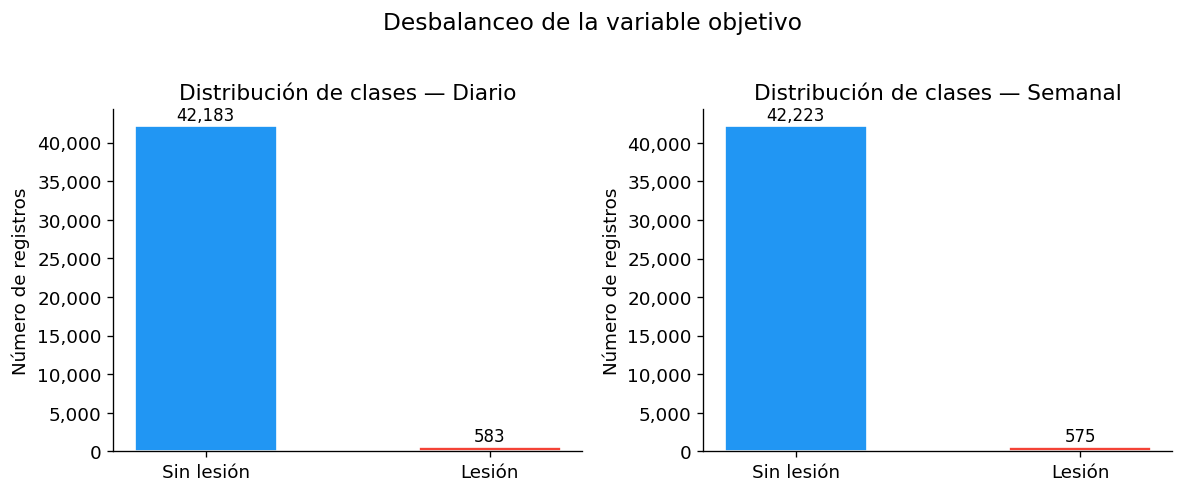

In [3]:
# Distribución de injury 
for label, df in [("Daily", df_daily), ("Weekly", df_weekly)]:
    vc   = df['injury'].value_counts() #Cuenta cuantos datos son injury y cuantos no
    rate = df['injury'].mean() * 100 #Tasa de lesiones 
    print(f"[{label}]  injury=0: {vc[0]:,}  |  injury=1: {vc[1]:,}  |  "
          f"Tasa: {rate:.2f}%  |  Ratio: 1:{vc[0]/vc[1]:.0f}") # Print de la distribución de injury

# Gráfico 1
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # Una fila y dos columnas
for ax, (label, df) in zip(axes, [("Diario", df_daily), ("Semanal", df_weekly)]): # Unir los dos graficos
    counts = df['injury'].value_counts().sort_index()
    bars   = ax.bar(['Sin lesión', 'Lesión'], counts.values,
                    color=PALETTE, edgecolor='white', width=0.5) # Dibujo de las barras
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 200,
                f'{val:,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Distribución de clases — {label}')
    ax.set_ylabel('Número de registros')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Separadores en los miles para que los números sean más legibles
plt.suptitle('Desbalanceo de la variable objetivo', fontsize=14, y=1.02)
plt.tight_layout() # Ajuste para evitar que titulos y ejes se monten unos encima de otros
plt.savefig(os.path.join(BASE_DIR, 'Graf01_desbalanceo_clases.png'), bbox_inches='tight') # guardar el gráfico como png
plt.show() #Enseñar el gráfico

### 1.2 Análisis por atleta

Observaciones semanales — Media: 578 | Min: 43 | Max: 1791
Lesiones por atleta    — Media: 7.8 | Max: 35
Atletas con 0 lesiones: 13
Atletas con 1+ lesion:  61


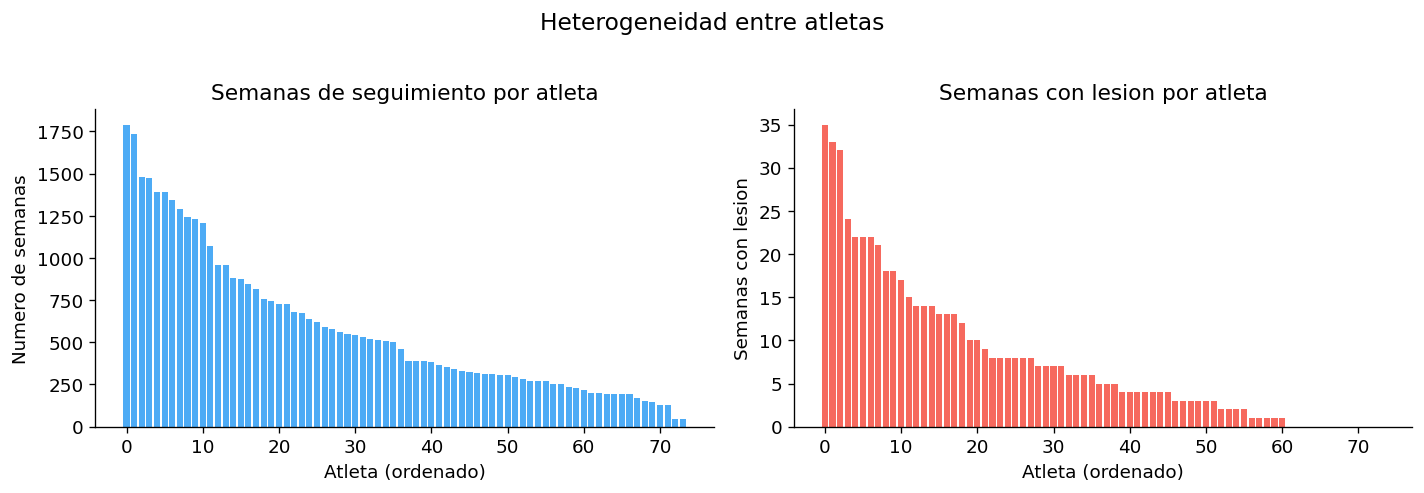

In [4]:
# Heterogeneidad entre atletas 
obs_por_atleta = df_weekly.groupby('Athlete ID').size() # Con esto podemos saber cuanto tiempo lleva cada atleta en el estudio
lesiones_por_atleta = df_weekly.groupby('Athlete ID')['injury'].sum() # Con esto la cantidad de lesiones que ha tenido cada atleta

print(f"Observaciones semanales — Media: {obs_por_atleta.mean():.0f} | "
      f"Min: {obs_por_atleta.min()} | Max: {obs_por_atleta.max()}")
print(f"Lesiones por atleta    — Media: {lesiones_por_atleta.mean():.1f} | "
      f"Max: {lesiones_por_atleta.max()}")
print(f"Atletas con 0 lesiones: {(lesiones_por_atleta==0).sum()}")
print(f"Atletas con 1+ lesion:  {(lesiones_por_atleta>=1).sum()}")

# Gráfico 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(obs_por_atleta)),
            obs_por_atleta.sort_values(ascending=False).values,
            color='#2196F3', alpha=0.8)
axes[0].set_title('Semanas de seguimiento por atleta')
axes[0].set_xlabel('Atleta (ordenado)')
axes[0].set_ylabel('Numero de semanas')

axes[1].bar(range(len(lesiones_por_atleta)),
            lesiones_por_atleta.sort_values(ascending=False).values,
            color='#F44336', alpha=0.8)
axes[1].set_title('Semanas con lesion por atleta')
axes[1].set_xlabel('Atleta (ordenado)')
axes[1].set_ylabel('Semanas con lesion')

plt.suptitle('Heterogeneidad entre atletas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf02_atletas.png'), bbox_inches='tight')
plt.show()

### 1.3 Cálculo del ACWR y análisis por clase

In [5]:
# ACWR (Acute Chronic Workload Ratio) nuestra principal medida de carga de entrenamiento
df_weekly['chronic_kms'] = (df_weekly['total kms'] + df_weekly['total kms.1'] + df_weekly['total kms.2']) / 3 # Carga cronica teniendo en cuenta los kkilometros usados en las ultimas 3 semanas

df_weekly['ACWR'] = np.where(
    df_weekly['chronic_kms'] > 0,
    df_weekly['total kms'] / df_weekly['chronic_kms'],
    np.nan
) # Creación de la variable ACWR usando la variable de kilometros "cronicos" solo en caso de ser mayores que cero para evitar errores, en caso de ser 0 poner un NaN
df_weekly['ACWR'] = df_weekly['ACWR'].clip(upper=3.0) # Al volver de vacaciones o de una lesión este valor puede dispararse, por ello lo limitamos a un maximo de 3, por lo que en caso de superarse ese valor se quedaría en 3

acwr_by_injury = df_weekly.groupby('injury')['ACWR'].mean() # Calculamos el ACWR por lesionado o no para ver la existencia de diferencias entre ellos
print(f"ACWR medio sin lesion: {acwr_by_injury[0]:.3f}") # ACWR medio para no lesionados
print(f"ACWR medio con lesion: {acwr_by_injury[1]:.3f}") # ACWR medio para lesionados
print(f"Diferencia relativa: "f"{(acwr_by_injury[1]-acwr_by_injury[0])/acwr_by_injury[0]*100:+.1f}%") # Diferencia relativa entre ambos casos

# Comparacion variables clave entre lesionados y no lesionados para analizar las posibles diferencias entre las clases
features_analisis = {
    'total kms':  'Kilometros totales',
    'ACWR':       'ACWR',
    'avg exertion': 'Esfuerzo percibido (media)',
    'avg recovery': 'Recuperacion percibida (media)',
    'nr. rest days': 'Dias de descanso',
    'nr. tough sessions (effort in Z5, T1 or T2)': 'Sesiones duras',
    'max km one day': 'Maximo km en un dia',
    'total km Z5-T1-T2': 'km alta intensidad',
}
print(f"\n{'Variable':<40} {'Sin lesion':>12} {'Lesion':>12} {'D%':>8}")
print("-" * 75)
for col, label in features_analisis.items():
    m0   = df_weekly[df_weekly['injury']==0][col].mean()
    m1   = df_weekly[df_weekly['injury']==1][col].mean()
    diff = (m1 - m0) / abs(m0) * 100 if m0 != 0 else np.nan
    print(f"{label:<40} {m0:>12.3f} {m1:>12.3f} {diff:>+8.1f}%")

ACWR medio sin lesion: 1.046
ACWR medio con lesion: 1.086
Diferencia relativa: +3.8%

Variable                                   Sin lesion       Lesion       D%
---------------------------------------------------------------------------
Kilometros totales                             49.512       51.856     +4.7%
ACWR                                            1.046        1.086     +3.8%
Esfuerzo percibido (media)                      0.319        0.404    +26.8%
Recuperacion percibida (media)                  0.255        0.300    +17.6%
Dias de descanso                                1.882        1.353    -28.1%
Sesiones duras                                  0.927        1.146    +23.6%
Maximo km en un dia                            13.999       14.770     +5.5%
km alta intensidad                              4.049        5.179    +27.9%


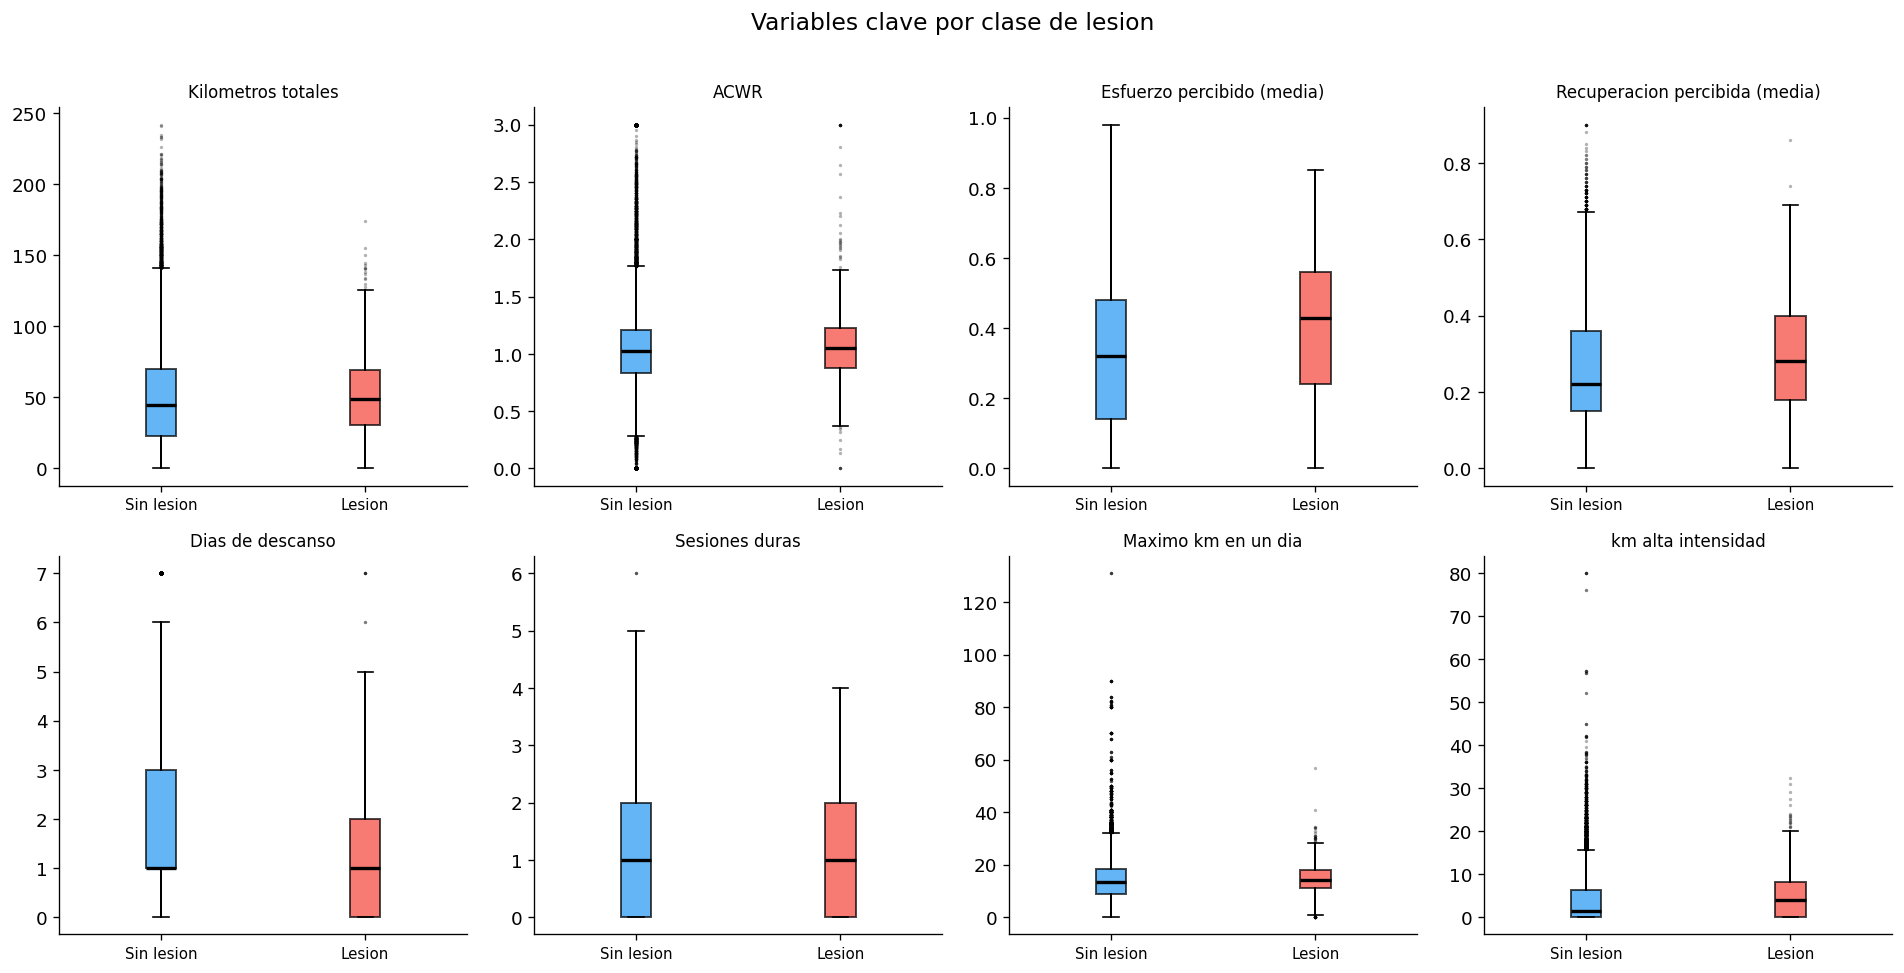

In [6]:
# Gráfico 3: Boxplots por clase para analizar los datos gráficamente
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
valid_features = [(col, lbl) for col, lbl in features_analisis.items()
                  if col in df_weekly.columns]
for ax, (col, label) in zip(axes, valid_features):
    data_0 = df_weekly[df_weekly['injury']==0][col].dropna()
    data_1 = df_weekly[df_weekly['injury']==1][col].dropna()
    bp = ax.boxplot([data_0, data_1], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3),
                    whiskerprops=dict(linewidth=1.2),
                    boxprops=dict(linewidth=1.2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Sin lesion', 'Lesion'], fontsize=9)
    ax.set_title(label, fontsize=10)
plt.suptitle('Variables clave por clase de lesion', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf03_boxplots_variables.png'), bbox_inches='tight')
plt.show()

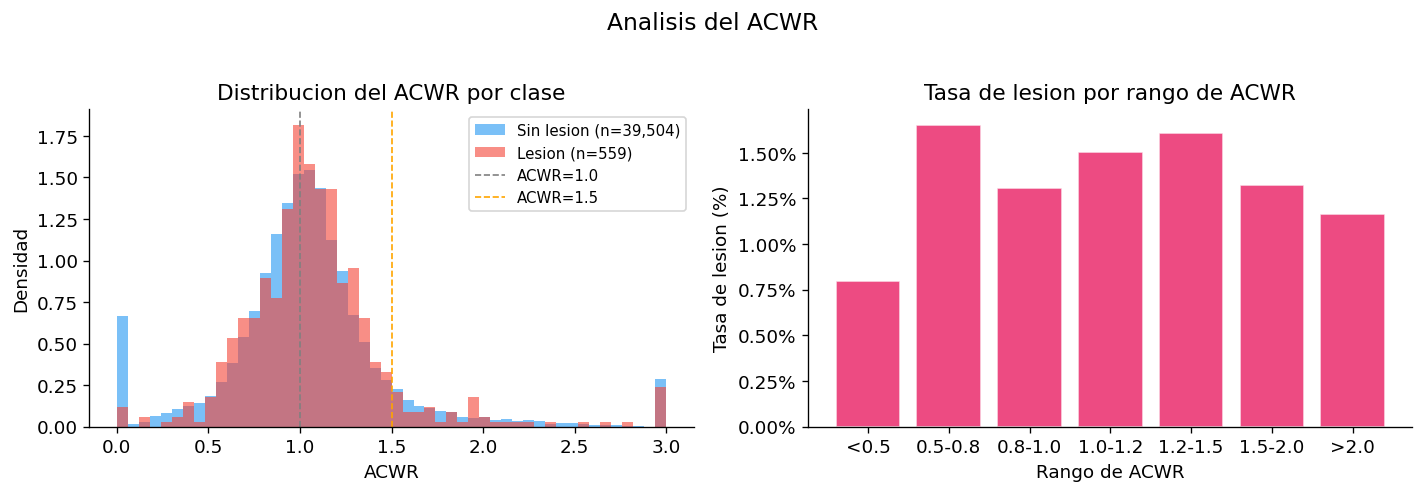

In [7]:
# Gráfico 4: ACWR por clase y tasa de lesion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for val, label, color in [(0, 'Sin lesion', '#2196F3'), (1, 'Lesion', '#F44336')]:
    data = df_weekly[df_weekly['injury']==val]['ACWR'].dropna()
    axes[0].hist(data, bins=50, alpha=0.6, color=color,
                 label=f'{label} (n={len(data):,})', density=True)
axes[0].axvline(1.0, color='gray', linestyle='--', linewidth=1, label='ACWR=1.0')
axes[0].axvline(1.5, color='orange', linestyle='--', linewidth=1, label='ACWR=1.5')
axes[0].set_xlabel('ACWR'); axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribucion del ACWR por clase'); axes[0].legend(fontsize=9)

bins = [0, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.01]
labels_bins = ['<0.5','0.5-0.8','0.8-1.0','1.0-1.2','1.2-1.5','1.5-2.0','>2.0']
df_weekly['ACWR_bin'] = pd.cut(df_weekly['ACWR'], bins=bins, labels=labels_bins)
injury_rate_by_acwr = df_weekly.groupby('ACWR_bin', observed=True)['injury'].mean() * 100
axes[1].bar(injury_rate_by_acwr.index, injury_rate_by_acwr.values,
            color='#E91E63', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Rango de ACWR'); axes[1].set_ylabel('Tasa de lesion (%)')
axes[1].set_title('Tasa de lesion por rango de ACWR')
axes[1].yaxis.set_major_formatter(PercentFormatter(decimals=2))
plt.suptitle('Analisis del ACWR', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf04_ACWR_analisis.png'), bbox_inches='tight')
plt.show()

Top 10 correlaciones con injury:
max exertion               0.0516
avg exertion               0.0488
max recovery               0.0432
max training success       0.0385
avg training success       0.0354
avg recovery               0.0336
total km Z3-Z4-Z5-T1-T2    0.0278
min exertion               0.0251
min training success       0.0233
total km Z5-T1-T2          0.0230


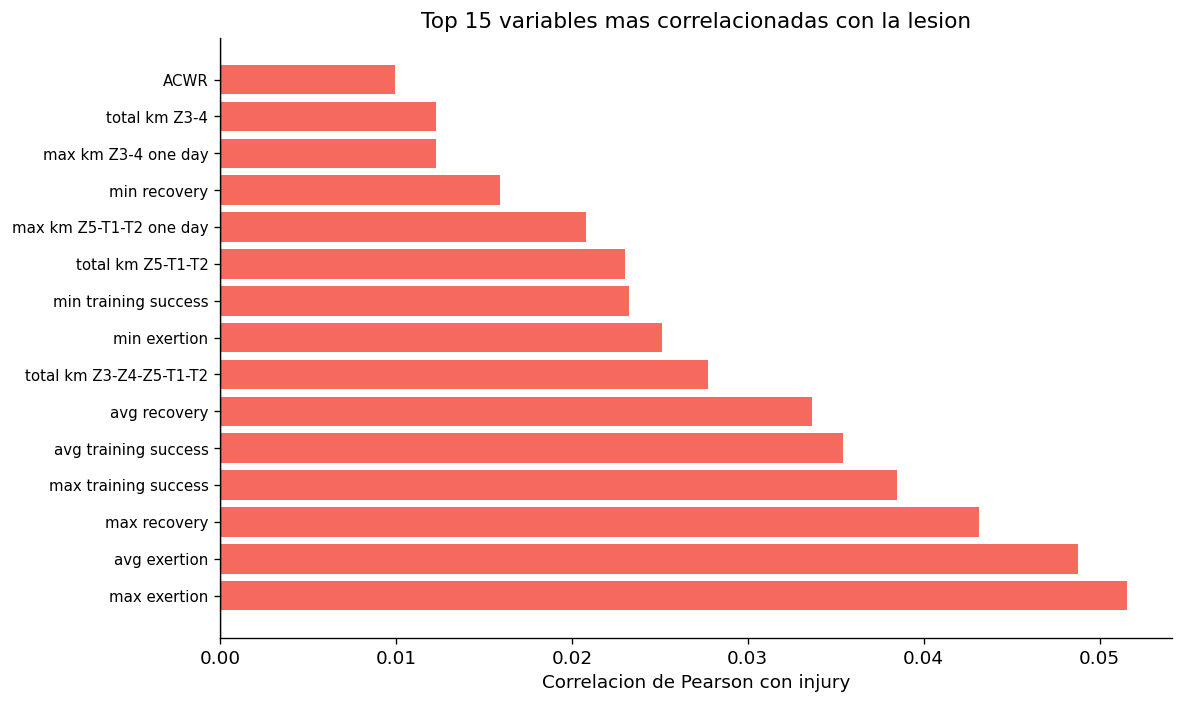

In [8]:
# Gráfico 5: Correlaciones con injury 
base_numeric_cols = [
    c for c in df_weekly.columns
    if '.' not in c
    and c not in ['Athlete ID', 'Date', 'injury', 'ACWR_bin', 'chronic_kms']
    and df_weekly[c].dtype in [np.float64, np.int64]
]
corr_with_injury = (
    df_weekly[base_numeric_cols + ['ACWR', 'injury']]
    .corr()['injury'].drop('injury')
    .sort_values(key=abs, ascending=False)
)
print("Top 10 correlaciones con injury:")
print(corr_with_injury.head(10).round(4).to_string()) # Imprimir cuales de los factores tienen mayor correlación con las lesiones

top_corr    = corr_with_injury.head(15)
colors_corr = ['#F44336' if v > 0 else '#2196F3' for v in top_corr.values]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_corr)), top_corr.values, color=colors_corr, alpha=0.8)
ax.set_yticks(range(len(top_corr))); ax.set_yticklabels(top_corr.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion de Pearson con injury')
ax.set_title('Top 15 variables mas correlacionadas con la lesion')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf05_correlaciones.png'), bbox_inches='tight')
plt.show()

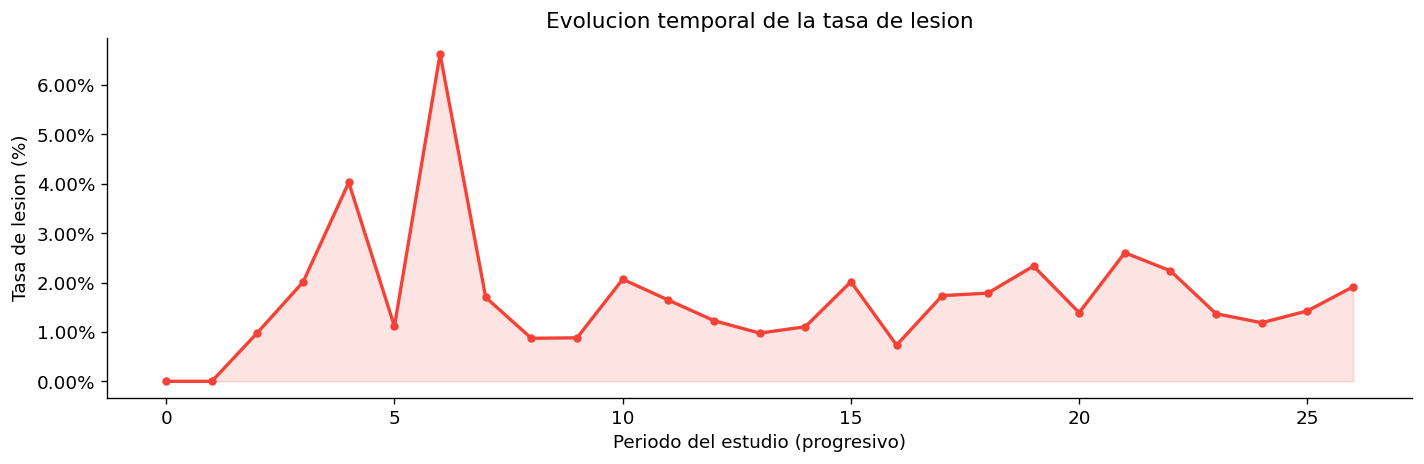

Bloque 1 completado.


In [9]:
# Gráfico 6: Evolucion temporal
df_weekly['date_bin'] = pd.cut(df_weekly['Date'], bins=27)
temporal = df_weekly.groupby('date_bin', observed=True)['injury'].mean() * 100
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(temporal)), temporal.values,
        color='#F44336', linewidth=2, marker='o', markersize=4)
ax.fill_between(range(len(temporal)), temporal.values, alpha=0.15, color='#F44336')
ax.set_xlabel('Periodo del estudio (progresivo)')
ax.set_ylabel('Tasa de lesion (%)')
ax.set_title('Evolucion temporal de la tasa de lesion')
ax.yaxis.set_major_formatter(PercentFormatter(decimals=2))
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf06_evolucion_temporal.png'), bbox_inches='tight')
plt.show()
print("Bloque 1 completado.")

---
## Bloque 2 — Ingeniería de variables

Construimos 8 variables nuevas a partir de los datos existentes:

| Variable | Definición | Justificación |
|----------|-----------|---------------|
| `ACWR` | Carga aguda / carga crónica (km) | Nakaoka et al. (2021) |
| `ACWR_exertion` | ACWR sobre esfuerzo percibido | Jones et al. (2017) |
| `monotony` | Media esfuerzo / variabilidad esfuerzo | Matos et al. (2020) |
| `strain` | Carga total × monotonía | Matos et al. (2020) |
| `km_change_w0_w1` | Cambio relativo km semana 0 vs 1 | Frandsen et al. (2025) |
| `km_change_w1_w2` | Cambio relativo km semana 1 vs 2 | Frandsen et al. (2025) |
| `recovery_trend` | Diferencia recuperación semana 0 vs 1 | — |
| `exertion_trend` | Diferencia esfuerzo semana 0 vs 1 | — |

In [10]:
# ACWR sobre kilometros (ya calculado en Bloque 1)
# Ya disponible en df_weekly['ACWR']

# ACWR sobre esfuerzo percibido 
df_weekly['chronic_exertion'] = (
    df_weekly['avg exertion'] + df_weekly['avg exertion.1'] + df_weekly['avg exertion.2']
) / 3
df_weekly['ACWR_exertion'] = np.where(
    df_weekly['chronic_exertion'] > 0,
    df_weekly['avg exertion'] / df_weekly['chronic_exertion'],
    np.nan
)
df_weekly['ACWR_exertion'] = df_weekly['ACWR_exertion'].clip(upper=3.0)

# Training Monotony 
df_weekly['exertion_range'] = df_weekly['max exertion'] - df_weekly['min exertion']
df_weekly['monotony'] = np.where(
    df_weekly['exertion_range'] > 0,
    df_weekly['avg exertion'] / (df_weekly['exertion_range'] / 2),
    np.nan
)
df_weekly['monotony'] = df_weekly['monotony'].clip(upper=10.0)

# Training Strain 
df_weekly['weekly_load'] = df_weekly['total kms'] * df_weekly['avg exertion']
df_weekly['strain'] = df_weekly['weekly_load'] * df_weekly['monotony']

# Ratios de cambio semanal 
df_weekly['km_change_w0_w1'] = np.where(
    df_weekly['total kms.1'] > 0,
    (df_weekly['total kms'] - df_weekly['total kms.1']) / df_weekly['total kms.1'],
    np.nan
)
df_weekly['km_change_w0_w1'] = df_weekly['km_change_w0_w1'].clip(-1, 2)

df_weekly['km_change_w1_w2'] = np.where(
    df_weekly['total kms.2'] > 0,
    (df_weekly['total kms.1'] - df_weekly['total kms.2']) / df_weekly['total kms.2'],
    np.nan
)
df_weekly['km_change_w1_w2'] = df_weekly['km_change_w1_w2'].clip(-1, 2)

# Tendencias 
df_weekly['recovery_trend'] = df_weekly['avg recovery'] - df_weekly['avg recovery.1']
df_weekly['exertion_trend']  = df_weekly['avg exertion'] - df_weekly['avg exertion.1']

print("Variables derivadas creadas correctamente.")

Variables derivadas creadas correctamente.


In [11]:
# Resumen comparativo por clase 
new_vars = ['ACWR','ACWR_exertion','monotony','strain',
            'km_change_w0_w1','km_change_w1_w2','recovery_trend','exertion_trend']

print(f"{'Variable':<22} {'Sin lesion':>12} {'Lesion':>12} {'D%':>8}")
print("-" * 58)
for v in new_vars:
    m0   = df_weekly[df_weekly['injury']==0][v].mean()
    m1   = df_weekly[df_weekly['injury']==1][v].mean()
    diff = (m1 - m0) / abs(m0) * 100 if m0 != 0 else np.nan
    print(f"{v:<22} {m0:>12.4f} {m1:>12.4f} {diff:>+8.1f}%")

Variable                 Sin lesion       Lesion       D%
----------------------------------------------------------
ACWR                         1.0459       1.0858     +3.8%
ACWR_exertion                1.0045       1.0431     +3.9%
monotony                     3.7210       3.1489    -15.4%
strain                      55.9246      60.7791     +8.7%
km_change_w0_w1              0.1069       0.1173     +9.8%
km_change_w1_w2              0.1108       0.2010    +81.4%
recovery_trend               0.0003       0.0045  +1215.5%
exertion_trend               0.0002       0.0097  +5482.8%


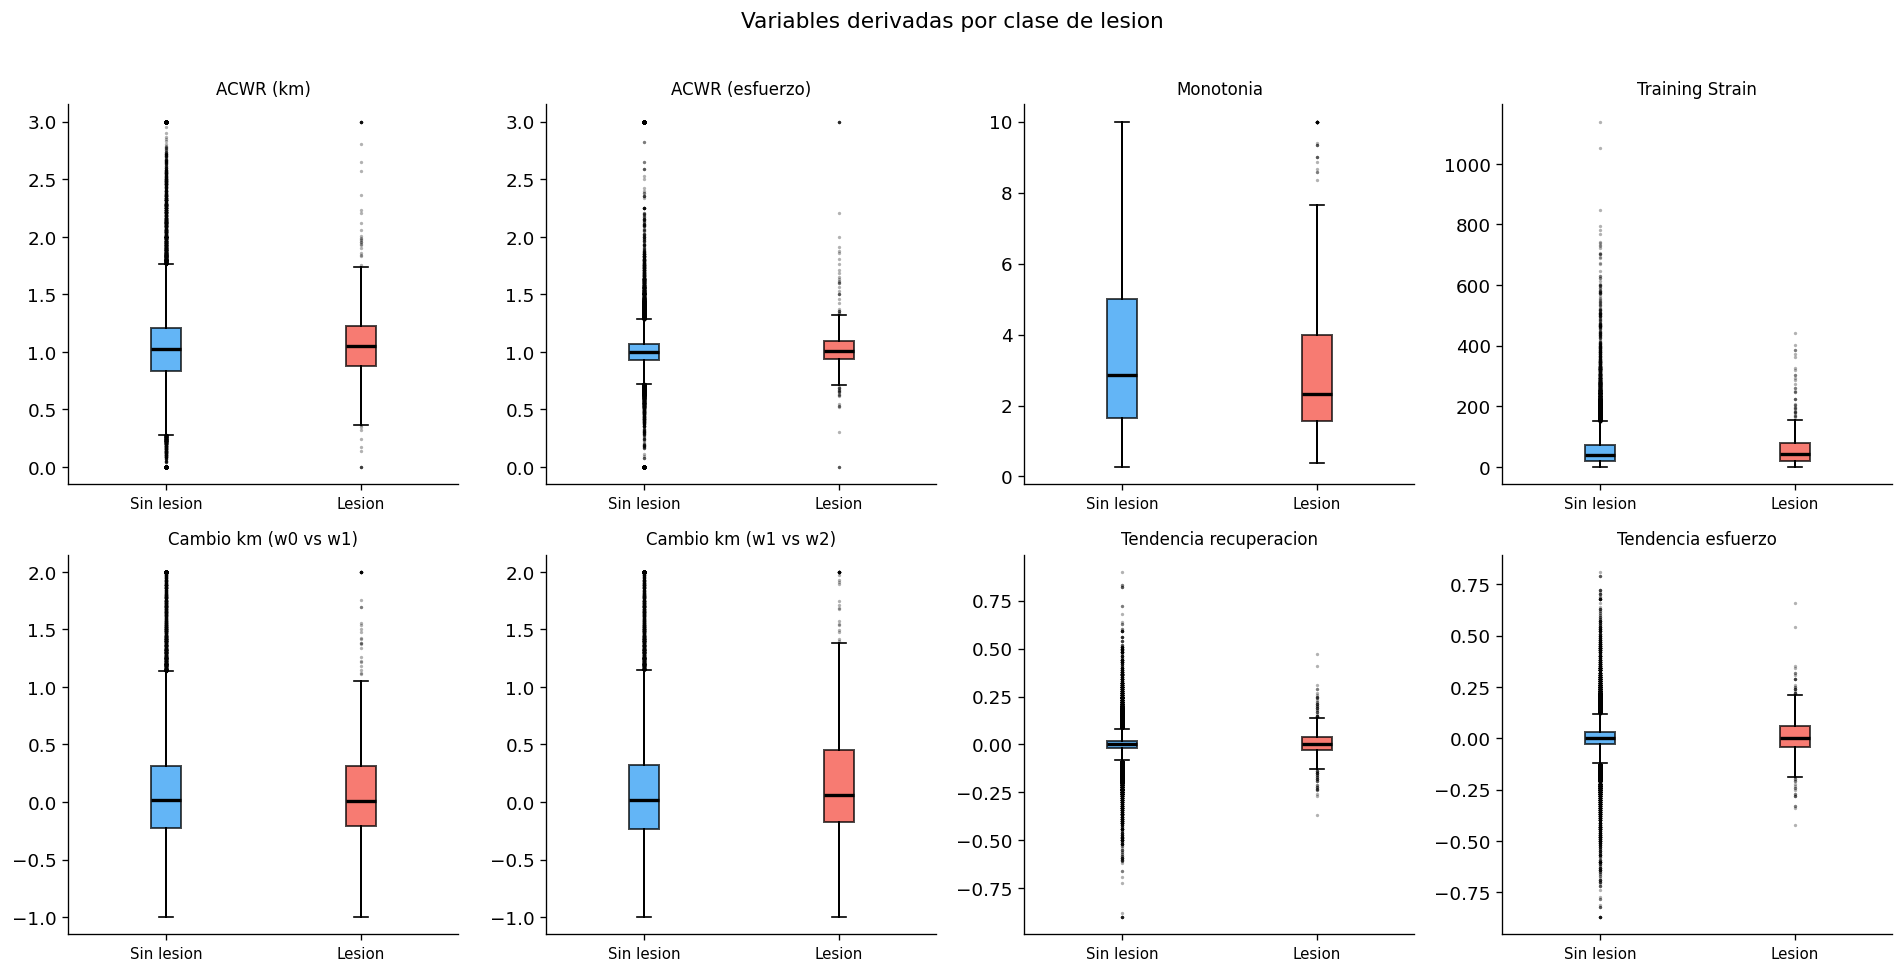

Bloque 2 completado.


In [12]:
# Gráfico 7: Boxplots variables derivadas 
new_vars_labels = {
    'ACWR':             'ACWR (km)',
    'ACWR_exertion':    'ACWR (esfuerzo)',
    'monotony':         'Monotonia',
    'strain':           'Training Strain',
    'km_change_w0_w1':  'Cambio km (w0 vs w1)',
    'km_change_w1_w2':  'Cambio km (w1 vs w2)',
    'recovery_trend':   'Tendencia recuperacion',
    'exertion_trend':   'Tendencia esfuerzo',
}
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, (col, label) in zip(axes, new_vars_labels.items()):
    data_0 = df_weekly[df_weekly['injury']==0][col].dropna()
    data_1 = df_weekly[df_weekly['injury']==1][col].dropna()
    bp = ax.boxplot([data_0, data_1], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3),
                    whiskerprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Sin lesion', 'Lesion'], fontsize=9)
    ax.set_title(label, fontsize=10)
plt.suptitle('Variables derivadas por clase de lesion', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf07_features_derivadas.png'), bbox_inches='tight')
plt.show()
print("Bloque 2 completado.")

---
## Bloque 3 — Preparación para modelado

Este bloque realiza tres operaciones fundamentales antes de entrenar los modelos:

1. **Selección de features** — 38 variables organizadas en 4 grupos
2. **Imputación de NaN** — mediana por atleta para respetar diferencias individuales  
3. **Split temporal 70/30** — los primeros 70% del periodo como train, el último 30% como test


In [13]:
# Selección de features 
BASE_FEATURES = [
    'nr. sessions', 'nr. rest days', 'total kms', 'max km one day',
    'total km Z3-Z4-Z5-T1-T2', 'nr. tough sessions (effort in Z5, T1 or T2)',
    'nr. days with interval session', 'total km Z3-4', 'total km Z5-T1-T2',
    'total hours alternative training', 'nr. strength trainings',
    'avg exertion', 'min exertion', 'max exertion',
    'avg training success', 'min training success', 'max training success',
    'avg recovery', 'min recovery', 'max recovery',
]
LAG1_FEATURES = [
    'total kms.1', 'avg exertion.1', 'avg recovery.1',
    'nr. sessions.1', 'nr. rest days.1',
    'nr. tough sessions (effort in Z5, T1 or T2).1',
    'total km Z5-T1-T2.1',
]
LAG2_FEATURES = [
    'total kms.2', 'avg exertion.2', 'avg recovery.2',
]
DERIVED_FEATURES = [
    'ACWR', 'ACWR_exertion', 'monotony', 'strain',
    'km_change_w0_w1', 'km_change_w1_w2',
    'recovery_trend', 'exertion_trend',
]
ALL_FEATURES = BASE_FEATURES + LAG1_FEATURES + LAG2_FEATURES + DERIVED_FEATURES
print(f"Total features seleccionadas: {len(ALL_FEATURES)}")
print(f"  Base: {len(BASE_FEATURES)} | Lag-1: {len(LAG1_FEATURES)} | "
      f"Lag-2: {len(LAG2_FEATURES)} | Derivadas: {len(DERIVED_FEATURES)}")

Total features seleccionadas: 38
  Base: 20 | Lag-1: 7 | Lag-2: 3 | Derivadas: 8


In [ ]:
# Imputacion de NaN
print(f"NaN antes de imputacion: {df_weekly[ALL_FEATURES].isnull().sum().sum():,}")

for feat in DERIVED_FEATURES:
    if df_weekly[feat].isna().sum() > 0:
        df_weekly[feat] = df_weekly.groupby('Athlete ID')[feat].transform(
            lambda x: x.fillna(x.median())
        )
        df_weekly[feat] = df_weekly[feat].fillna(df_weekly[feat].median())

print(f"NaN despues de imputacion: {df_weekly[ALL_FEATURES].isnull().sum().sum():,}")

NaN antes de imputacion: 22,006
NaN despues de imputacion: 0


In [ ]:
# Split temporal 70/30
from sklearn.preprocessing import StandardScaler

SPLIT_DATE = df_weekly['Date'].quantile(0.70)

train_mask = df_weekly['Date'] <= SPLIT_DATE
test_mask  = df_weekly['Date'] >  SPLIT_DATE

X_train = df_weekly.loc[train_mask, ALL_FEATURES].copy()
X_test  = df_weekly.loc[test_mask,  ALL_FEATURES].copy()
y_train = df_weekly.loc[train_mask, 'injury'].copy()
y_test  = df_weekly.loc[test_mask,  'injury'].copy()

# Estandarizacion (fit solo sobre train para evitar data leakage)
scaler       = StandardScaler()
X_train_sc   = pd.DataFrame(scaler.fit_transform(X_train),
                             columns=ALL_FEATURES, index=X_train.index)
X_test_sc    = pd.DataFrame(scaler.transform(X_test),
                             columns=ALL_FEATURES, index=X_test.index)

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Split temporal (cutoff Date={SPLIT_DATE:.0f})")
print(f"  Train: {len(X_train):,} obs. | lesiones: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"  Test:  {len(X_test):,} obs.  | lesiones: {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print(f"  Ratio desbalanceo train: 1:{SCALE_POS_WEIGHT:.0f}")
print(f"  scale_pos_weight XGBoost: {SCALE_POS_WEIGHT:.1f}")

Split temporal (cutoff Date=1759)
  Train: 29,964 obs. | lesiones: 349 (1.16%)
  Test:  12,834 obs.  | lesiones: 226 (1.76%)
  Ratio desbalanceo train: 1:85
  scale_pos_weight XGBoost: 84.9


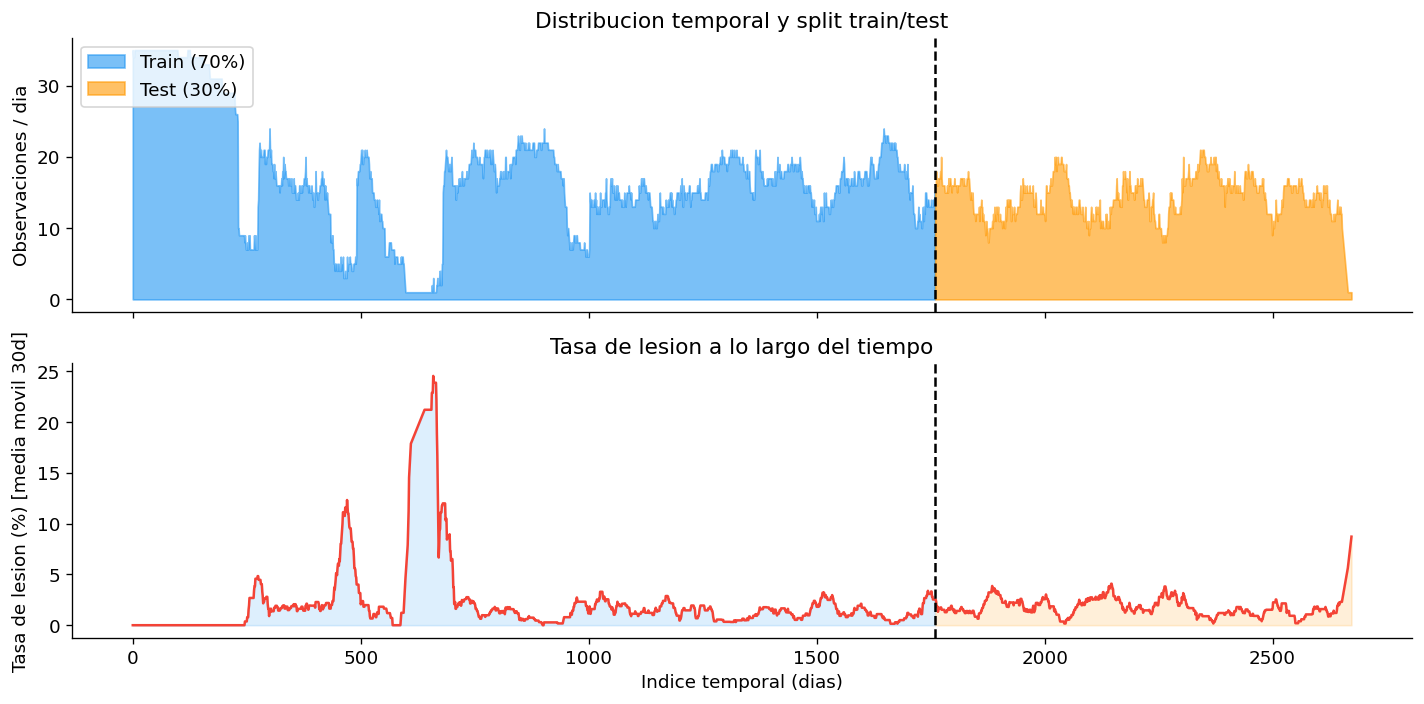

Bloque 3 completado. Listo para modelado.


In [ ]:
# Gráfico 9: Esquema del split temporal
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

obs_by_date = df_weekly.groupby('Date').size()
axes[0].fill_between(obs_by_date.index, obs_by_date.values,
                     where=obs_by_date.index <= SPLIT_DATE,
                     alpha=0.6, color='#2196F3', label='Train (70%)')
axes[0].fill_between(obs_by_date.index, obs_by_date.values,
                     where=obs_by_date.index > SPLIT_DATE,
                     alpha=0.6, color='#FF9800', label='Test (30%)')
axes[0].axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1.5)
axes[0].set_ylabel('Observaciones / dia')
axes[0].set_title('Distribucion temporal y split train/test')
axes[0].legend(loc='upper left')

inj_by_date = df_weekly.groupby('Date')['injury'].mean() * 100
smooth = inj_by_date.rolling(window=30, min_periods=1).mean()
axes[1].plot(smooth.index, smooth.values, color='#F44336', linewidth=1.5)
axes[1].fill_between(smooth.index, smooth.values,
                     where=smooth.index <= SPLIT_DATE, alpha=0.15, color='#2196F3')
axes[1].fill_between(smooth.index, smooth.values,
                     where=smooth.index > SPLIT_DATE, alpha=0.15, color='#FF9800')
axes[1].axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Indice temporal (dias)')
axes[1].set_ylabel('Tasa de lesion (%) [media movil 30d]')
axes[1].set_title('Tasa de lesion a lo largo del tiempo')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf09_split_temporal.png'), bbox_inches='tight')
plt.show()
print("Bloque 3 completado. Listo para modelado.")

---
## Bloque 4 — Modelos predictivos

En este bloque entrenamos y evaluamos tres algoritmos de clasificación supervisada para predecir
la variable `injury`. La selección de modelos responde a criterios de complementariedad:

| Modelo | Justificación |
|--------|---------------|
| **Regresión Logística** | Modelo lineal interpretable; actúa como baseline. Uso de `class_weight='balanced'` para compensar el desbalanceo. |
| **Random Forest** | Ensemble no lineal basado en bagging; captura interacciones sin requerir ingeniería manual. Mismo ajuste por `class_weight`. |
| **XGBoost** | Gradient boosting con regularización; permite ajustar `scale_pos_weight` para el desbalanceo extremo (~85:1). |

 **Nota sobre la evaluación:** Dado el desbalanceo severo (~1.2% de lesiones), el accuracy
no es una métrica informativa (un modelo trivial que prediga siempre 0 alcanzaría ~98.8%).
La evaluación se centra en **ROC-AUC**, **F1**, **precision** y **recall** sobre la clase
minoritaria.

In [ ]:
# Imports Bloque 4
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import time

print("Librerias de modelado cargadas correctamente.")

Librerias de modelado cargadas correctamente.


### 4.1 Entrenamiento de los tres modelos

Cada modelo se entrena sobre `X_train_sc` (datos estandarizados) y `y_train`, y se evalúa
sobre el conjunto de test. Se registran las probabilidades predichas para calcular ROC-AUC
y las curvas correspondientes.

In [ ]:
# Definición y entrenamiento
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=SCALE_POS_WEIGHT,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
}

results = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    elapsed = time.time() - t0
    
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'avg_prec':  average_precision_score(y_test, y_proba),
        'time':      elapsed,
    }
    print(f"✓ {name:25s} entrenado en {elapsed:.1f}s  |  "
          f"ROC-AUC={results[name]['roc_auc']:.4f}  "
          f"F1={results[name]['f1']:.4f}  "
          f"Recall={results[name]['recall']:.4f}")

✓ Logistic Regression       entrenado en 0.2s  |  ROC-AUC=0.6015  F1=0.0430  Recall=0.7345
✓ Random Forest             entrenado en 1.2s  |  ROC-AUC=0.5943  F1=0.0435  Recall=0.0885
✓ XGBoost                   entrenado en 0.7s  |  ROC-AUC=0.5545  F1=0.0343  Recall=0.0708


### 4.2 Tabla comparativa de rendimiento

In [ ]:
# Tabla resumen
metrics_df = pd.DataFrame({
    name: {
        'ROC-AUC':           r['roc_auc'],
        'Average Precision':  r['avg_prec'],
        'F1 (clase 1)':      r['f1'],
        'Precision (clase 1)': r['precision'],
        'Recall (clase 1)':  r['recall'],
    }
    for name, r in results.items()
}).T

metrics_df = metrics_df.round(4)
print("\n" + "=" * 75)
print("COMPARATIVA DE RENDIMIENTO — CONJUNTO DE TEST")
print("=" * 75)
print(metrics_df.to_string())
print("=" * 75)

# Mejor modelo por ROC-AUC
best_name = metrics_df['ROC-AUC'].idxmax()
print(f"\nMejor modelo por ROC-AUC: {best_name} ({metrics_df.loc[best_name, 'ROC-AUC']:.4f})")


COMPARATIVA DE RENDIMIENTO — CONJUNTO DE TEST
                     ROC-AUC  Average Precision  F1 (clase 1)  Precision (clase 1)  Recall (clase 1)
Logistic Regression   0.6015             0.0227        0.0430               0.0221            0.7345
Random Forest         0.5943             0.0235        0.0435               0.0289            0.0885
XGBoost               0.5545             0.0241        0.0343               0.0226            0.0708

Mejor modelo por ROC-AUC: Logistic Regression (0.6015)


### 4.3 Matrices de confusión

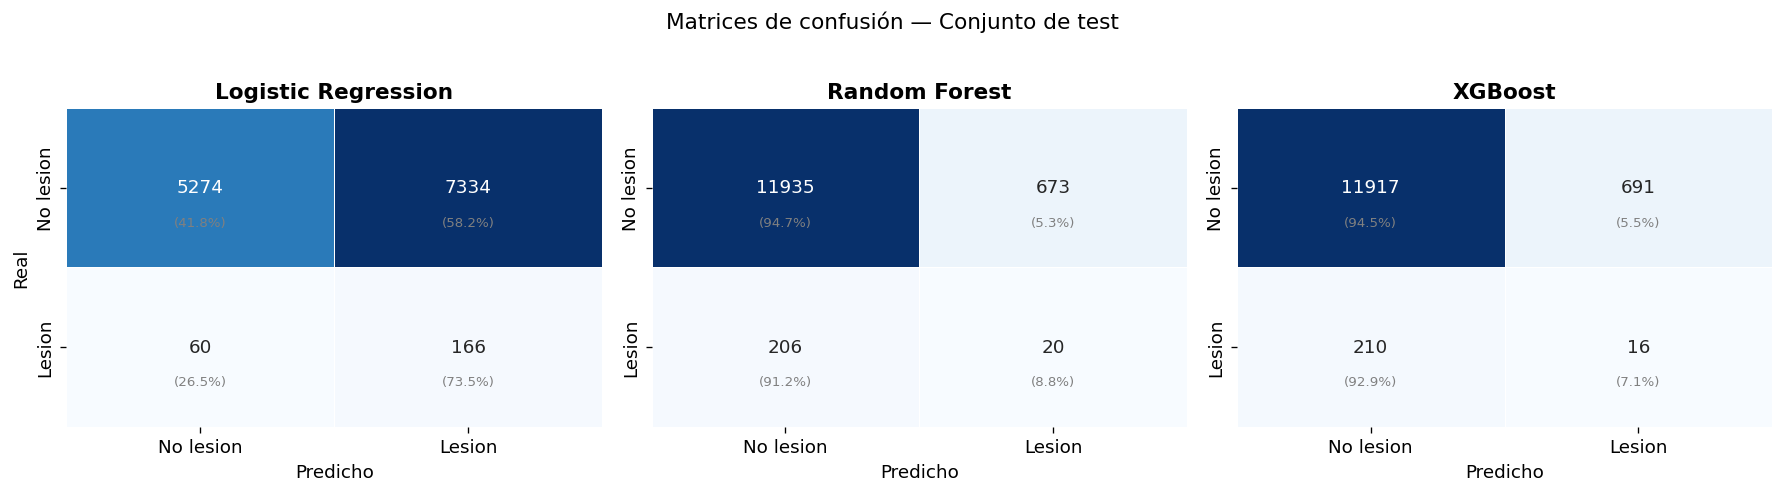

In [ ]:
# Gráfico 10: Matrices de confusión 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    # Normalizar por fila para mostrar tasas
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No lesion', 'Lesion'],
                yticklabels=['No lesion', 'Lesion'],
                cbar=False, linewidths=0.5)
    
    # Añadir porcentajes
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f"({cm_norm[i, j]:.1%})",
                    ha='center', va='center', fontsize=8, color='gray')
    
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Real' if ax == axes[0] else '')
    ax.set_xlabel('Predicho')

plt.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf10_confusion_matrices.png'), bbox_inches='tight')
plt.show()

### 4.4 Curvas ROC y Precision-Recall

En problemas con desbalanceo severo, la curva ROC puede ser optimista porque la clase
mayoritaria domina la tasa de falsos positivos. Por eso complementamos con la curva
Precision-Recall, que evalúa directamente el rendimiento sobre la clase minoritaria.

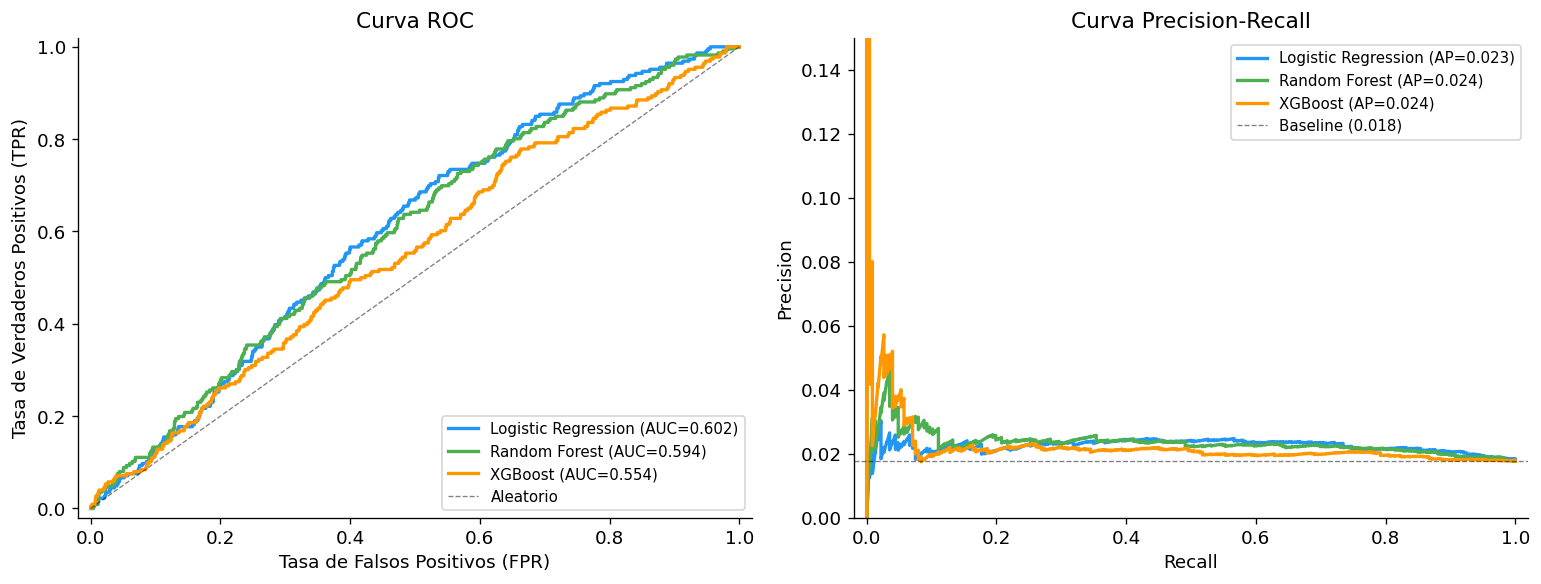

In [ ]:
# Gráfico 11: Curvas ROC y Precision-Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = {'Logistic Regression': '#2196F3', 'Random Forest': '#4CAF50', 'XGBoost': '#FF9800'}

# Curva ROC
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax1.plot(fpr, tpr, color=colors[name], linewidth=2,
             label=f"{name} (AUC={r['roc_auc']:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5, label='Aleatorio')
ax1.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax1.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])

# Curva Precision-Recall
baseline_pr = y_test.mean()
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ax2.plot(rec, prec, color=colors[name], linewidth=2,
             label=f"{name} (AP={r['avg_prec']:.3f})")
ax2.axhline(baseline_pr, color='k', linestyle='--', linewidth=0.8, alpha=0.5,
            label=f'Baseline ({baseline_pr:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([0, max(0.15, baseline_pr * 5)])

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf11_roc_pr_curves.png'), bbox_inches='tight')
plt.show()

### 4.5 Importancia de variables

Analizamos qué variables contribuyen más a las predicciones de cada modelo:
- **Regresión Logística**: coeficientes estandarizados (valor absoluto).
- **Random Forest**: importancia por impureza (Gini).
- **XGBoost**: importancia por ganancia (gain).

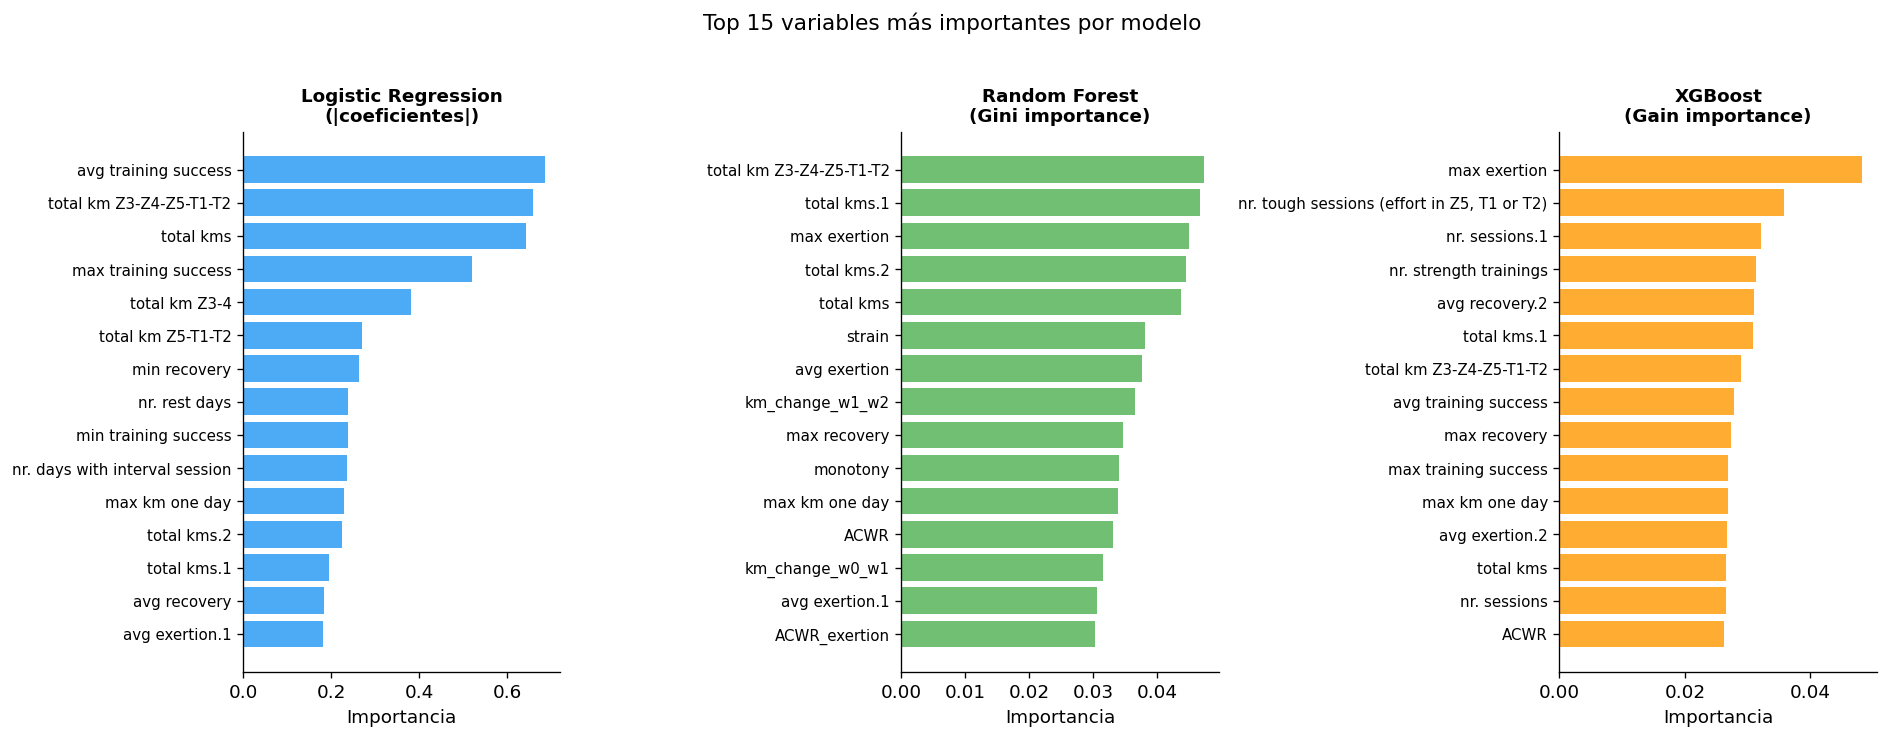

In [ ]:
# Importancia de variables por modelo 
TOP_N = 15

# Logistic Regression — coeficientes absolutos
lr_coefs = pd.Series(
    np.abs(results['Logistic Regression']['model'].coef_[0]),
    index=ALL_FEATURES
).sort_values(ascending=False)

# Random Forest — importancia Gini
rf_imp = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

# XGBoost — importancia por ganancia
xgb_imp = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

# Gráfico 12: Top features por modelo 
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (imp, title, color) in zip(axes, [
    (lr_coefs.head(TOP_N),  'Logistic Regression\n(|coeficientes|)', '#2196F3'),
    (rf_imp.head(TOP_N),    'Random Forest\n(Gini importance)',       '#4CAF50'),
    (xgb_imp.head(TOP_N),   'XGBoost\n(Gain importance)',             '#FF9800'),
]):
    imp_sorted = imp.sort_values(ascending=True)
    ax.barh(range(len(imp_sorted)), imp_sorted.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(imp_sorted)))
    ax.set_yticklabels(imp_sorted.index, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Importancia')

plt.suptitle(f'Top {TOP_N} variables más importantes por modelo', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf12_feature_importance.png'), bbox_inches='tight')
plt.show()

In [ ]:
# Ranking de consenso
# Normalizamos cada ranking a [0,1] y promediamos posiciones
def rank_normalize(series):
    ranked = series.rank(ascending=False)
    return 1 - (ranked - 1) / (len(ranked) - 1)

consensus = pd.DataFrame({
    'LR':  rank_normalize(lr_coefs),
    'RF':  rank_normalize(rf_imp),
    'XGB': rank_normalize(xgb_imp),
})
consensus['Media'] = consensus.mean(axis=1)
consensus = consensus.sort_values('Media', ascending=False)

print("TOP 15 VARIABLES — RANKING DE CONSENSO (3 modelos)")
print("=" * 65)
print(consensus.head(15).round(3).to_string())
print("=" * 65)

TOP 15 VARIABLES — RANKING DE CONSENSO (3 modelos)
                            LR     RF    XGB  Media
total km Z3-Z4-Z5-T1-T2  0.973  1.000  0.838  0.937
total kms.1              0.676  0.973  0.865  0.838
total kms                0.946  0.892  0.676  0.838
avg training success     1.000  0.432  0.811  0.748
max training success     0.919  0.568  0.757  0.748
max km one day           0.730  0.730  0.730  0.730
total kms.2              0.703  0.919  0.541  0.721
max exertion             0.081  0.946  1.000  0.676
avg exertion             0.595  0.838  0.486  0.640
max recovery             0.216  0.784  0.784  0.595
nr. sessions.1           0.432  0.405  0.946  0.595
total km Z3-4            0.892  0.270  0.568  0.577
ACWR                     0.351  0.703  0.622  0.559
avg recovery.2           0.243  0.514  0.892  0.550
km_change_w0_w1          0.541  0.676  0.432  0.550


### 4.6 Análisis de sensibilidad al umbral de decisión

El umbral por defecto (0.5) no es óptimo en problemas con desbalanceo severo. Evaluamos
cómo varía el F1 del mejor modelo en función del umbral para identificar el punto de
equilibrio entre precision y recall.

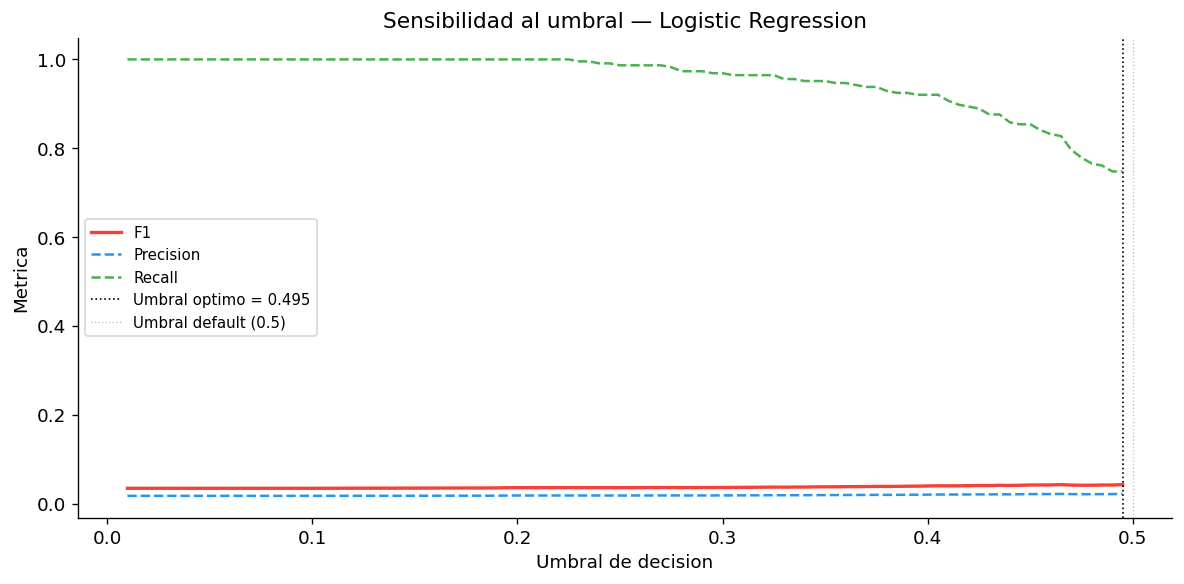

Umbral optimo (max F1): 0.495
  F1 = 0.0428  |  Precision = 0.0220  |  Recall = 0.7478

Comparativa con umbral default (0.5):
  F1 default:  0.0430
  F1 optimo:   0.0428 (-0.4%)


In [ ]:
# Gráfico 13: Sensibilidad al umbral
best_name = metrics_df['ROC-AUC'].idxmax()
best_proba = results[best_name]['y_proba']

thresholds = np.arange(0.01, 0.50, 0.005)
f1s, precs, recs = [], [], []

for t in thresholds:
    y_t = (best_proba >= t).astype(int)
    f1s.append(f1_score(y_test, y_t, zero_division=0))
    precs.append(precision_score(y_test, y_t, zero_division=0))
    recs.append(recall_score(y_test, y_t, zero_division=0))

optimal_idx = np.argmax(f1s)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s,  color='#F44336', linewidth=2, label='F1')
ax.plot(thresholds, precs, color='#2196F3', linewidth=1.5, linestyle='--', label='Precision')
ax.plot(thresholds, recs,  color='#4CAF50', linewidth=1.5, linestyle='--', label='Recall')
ax.axvline(optimal_threshold, color='black', linestyle=':', linewidth=1,
           label=f'Umbral optimo = {optimal_threshold:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5, label='Umbral default (0.5)')
ax.set_xlabel('Umbral de decision')
ax.set_ylabel('Metrica')
ax.set_title(f'Sensibilidad al umbral — {best_name}')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf13_threshold_analysis.png'), bbox_inches='tight')
plt.show()

print(f"Umbral optimo (max F1): {optimal_threshold:.3f}")
print(f"  F1 = {f1s[optimal_idx]:.4f}  |  "
      f"Precision = {precs[optimal_idx]:.4f}  |  "
      f"Recall = {recs[optimal_idx]:.4f}")

# Comparativa default vs óptimo
print(f"\nComparativa con umbral default (0.5):")
print(f"  F1 default:  {results[best_name]['f1']:.4f}")
print(f"  F1 optimo:   {f1s[optimal_idx]:.4f} ({(f1s[optimal_idx]/results[best_name]['f1']-1)*100:+.1f}%)")

### 4.7 Análisis de errores

Para entender dónde fallan los modelos, analizamos los falsos negativos (lesiones no
detectadas) y los falsos positivos (falsas alarmas). Esto es esencial para valorar la
utilidad práctica del sistema predictivo.

Distribucion de predicciones (Logistic Regression):
tipo
FP    7334
TN    5274
TP     166
FN      60


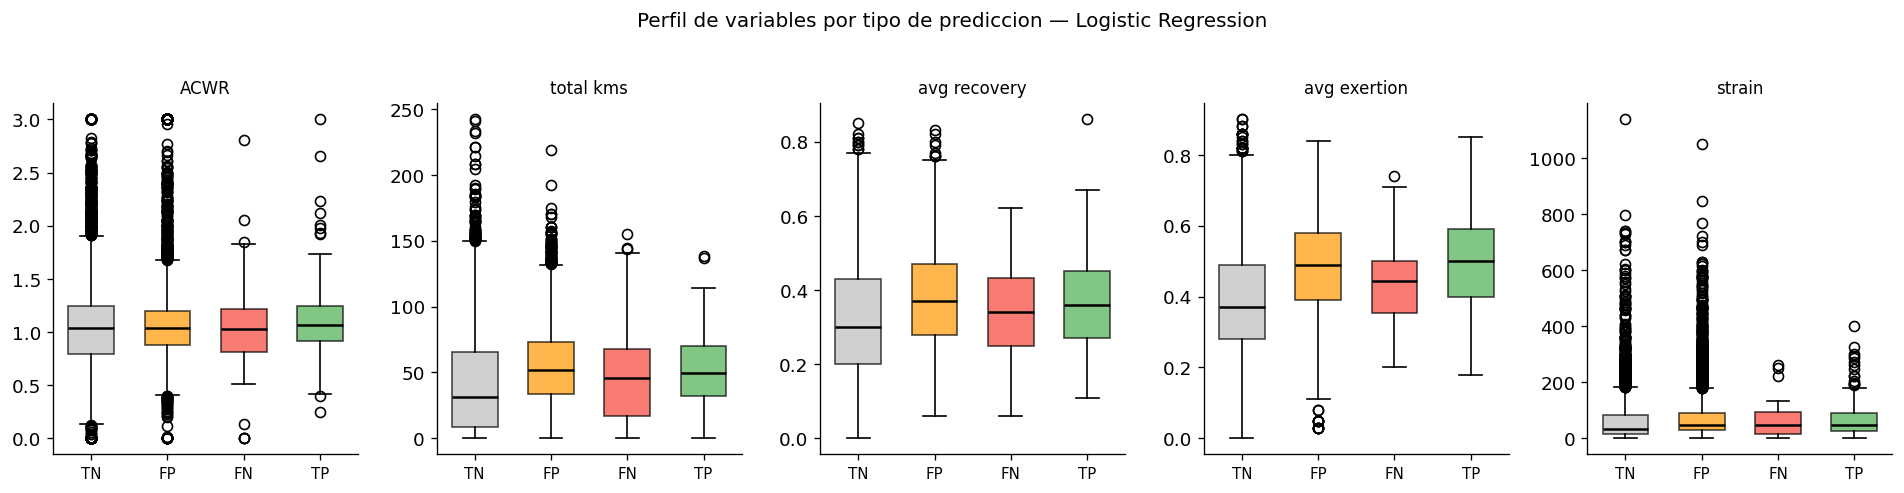


Perfil medio — Falsos Negativos vs Verdaderos Positivos:
-------------------------------------------------------
  ACWR                  FN=1.032  TP=1.105
  total kms             FN=52.047  TP=52.837
  avg recovery          FN=0.346  TP=0.364
  avg exertion          FN=0.435  TP=0.501
  strain                FN=62.427  TP=73.238


In [ ]:
# Análisis de errores del mejor modelo 
best_pred  = results[best_name]['y_pred']
best_proba_arr = results[best_name]['y_proba']

# Clasificación de errores
test_analysis = pd.DataFrame({
    'y_real':  y_test.values,
    'y_pred':  best_pred,
    'proba':   best_proba_arr,
}, index=X_test.index)

for feat in ['ACWR', 'total kms', 'avg recovery', 'avg exertion', 'strain', 'monotony']:
    test_analysis[feat] = df_weekly.loc[X_test.index, feat]

test_analysis['tipo'] = 'TN'
test_analysis.loc[(test_analysis['y_real']==1) & (test_analysis['y_pred']==1), 'tipo'] = 'TP'
test_analysis.loc[(test_analysis['y_real']==1) & (test_analysis['y_pred']==0), 'tipo'] = 'FN'
test_analysis.loc[(test_analysis['y_real']==0) & (test_analysis['y_pred']==1), 'tipo'] = 'FP'

print(f"Distribucion de predicciones ({best_name}):")
print(test_analysis['tipo'].value_counts().to_string())

# Gráfico 14: Perfil de errores
error_vars = ['ACWR', 'total kms', 'avg recovery', 'avg exertion', 'strain']
fig, axes = plt.subplots(1, len(error_vars), figsize=(16, 4))

tipo_colors = {'TP': '#4CAF50', 'FN': '#F44336', 'FP': '#FF9800', 'TN': '#BDBDBD'}
tipo_order = ['TN', 'FP', 'FN', 'TP']

for ax, var in zip(axes, error_vars):
    data_plot = [test_analysis.loc[test_analysis['tipo'] == t, var].dropna() for t in tipo_order]
    bp = ax.boxplot(data_plot, labels=tipo_order, patch_artist=True, widths=0.6,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, t in zip(bp['boxes'], tipo_order):
        patch.set_facecolor(tipo_colors[t])
        patch.set_alpha(0.7)
    ax.set_title(var, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle(f'Perfil de variables por tipo de prediccion — {best_name}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf14_error_analysis.png'), bbox_inches='tight')
plt.show()

# Estadísticas FN vs TP
print("\nPerfil medio — Falsos Negativos vs Verdaderos Positivos:")
print("-" * 55)
for var in error_vars:
    fn_mean = test_analysis.loc[test_analysis['tipo']=='FN', var].mean()
    tp_mean = test_analysis.loc[test_analysis['tipo']=='TP', var].mean()
    print(f"  {var:<20s}  FN={fn_mean:.3f}  TP={tp_mean:.3f}")

### 4.8 Resumen del Bloque 4

Los tres modelos han sido entrenados y evaluados sobre el conjunto de test con métricas
apropiadas para el contexto de desbalanceo. Los resultados principales se discutirán en
profundidad en el **Bloque 5 — Discusión**.

**Gráficos generadas en este bloque:**
- Gráfico 10: Matrices de confusión
- Gráfico 11: Curvas ROC y Precision-Recall
- Gráfico 12: Importancia de variables (top 15 por modelo)
- Gráfico 13: Sensibilidad al umbral de decisión
- Gráfico 14: Perfil de errores por tipo de predicción

---
## Bloque 5 — Discusión


### 5.1 Interpretación de los resultados principales

Los tres modelos entrenados presentan una capacidad predictiva limitada. La Regresión
Logística obtiene el mejor ROC-AUC (0.602), seguida del Random Forest (0.594) y
XGBoost (0.554). Estos valores, aunque superiores al azar (0.5), indican que la señal
predictiva contenida en las variables de carga de entrenamiento disponibles no es
suficiente para discriminar con fiabilidad entre semanas con y sin lesión.

La curva Precision-Recall resulta especialmente reveladora: los tres modelos alcanzan
un Average Precision en torno a 0.023-0.024, apenas superior al baseline de 0.018 que
correspondería a un clasificador aleatorio proporcional a la prevalencia. Esto confirma
que, en términos absolutos, la capacidad de los modelos para identificar correctamente
las semanas de lesión es muy reducida.

El análisis de las matrices de confusión refleja con claridad el trade-off entre
sensibilidad y especificidad que impone el desbalanceo extremo (~1.3% de lesiones).
La Regresión Logística, al aplicar `class_weight='balanced'`, alcanza un recall del
73.5% detecta casi tres de cada cuatro lesiones, pero a costa de una tasa de falsos
positivos del 58.2%: más de la mitad de las semanas sin lesión son clasificadas
erróneamente como positivas. Random Forest y XGBoost, en cambio, adoptan un
comportamiento mucho más conservador (recall del 8.8% y 7.1% respectivamente),
con una especificidad muy alta (~95%) pero a costa de dejar pasar la gran mayoría
de las lesiones.

Esta divergencia no es casual. La Regresión Logística, al ser un modelo lineal con
un hiperplano de decisión único, responde de forma más directa al rebalanceo de pesos:
desplaza su frontera de decisión hacia la clase mayoritaria de manera global. Los
modelos de ensemble, por su estructura basada en particiones del espacio de features,
tienden a ser más conservadores incluso con ajustes de peso, porque cada árbol
individual sigue viendo una proporción abrumadora de negativos en sus nodos.

### 5.2 Importancia de variables y su interpretación

El ranking de consenso de los tres modelos sitúa los kilómetros en zonas de alta
intensidad (`total km Z3-Z4-Z5-T1-T2`) como la variable más relevante, con una
puntuación media de 0.937. Le siguen los kilómetros totales de la semana anterior
(`total kms.1`, 0.838) y de la semana actual (`total kms`, 0.838). Este resultado
es coherente con la literatura: la carga de entrenamiento en volumen y, sobre todo,
su componente de alta intensidad, aparecen consistentemente como factores asociados
al riesgo lesional (Jones et al., 2017; Matos et al., 2020).

Es significativo que las métricas de éxito percibido del entrenamiento (`avg training
success`, `max training success`) ocupen posiciones altas en el ranking (0.748 ambas).
Estas variables, que capturan la percepción subjetiva del atleta sobre la calidad de
sus sesiones, podrían estar actuando como proxies de un estado fisiológico subyacente:
un atleta que reporta consistentemente baja satisfacción con su entrenamiento podría
estar experimentando fatiga acumulada o los primeros síntomas de una sobrecarga.

El ACWR, a pesar de ser la métrica más citada en la literatura sobre predicción de
lesiones, ocupa la posición 13 en el ranking de consenso (0.559). Esta posición
relativamente modesta es consistente con las críticas metodológicas señaladas por
Impellizzeri et al. (2020), quienes cuestionaron la capacidad predictiva real del
ACWR cuando se controla por sus componentes. En nuestro análisis, al incluir
simultáneamente el ACWR y las variables de volumen de las que se deriva, es
esperable que los modelos asignen mayor importancia a las variables brutas, que
contienen más información que el cociente.

La presencia de variables con retardo temporal (`total kms.1`, `total kms.2`,
`avg recovery.2`) en posiciones altas del ranking refuerza la idea de que el riesgo
de lesión no depende únicamente de la carga de la semana actual, sino de la
acumulación y la dinámica de carga en las semanas previas. Esto valida la decisión
de diseño de incluir la ventana de tres semanas en el feature set.

### 5.3 Comparación con la literatura existente

Los niveles de rendimiento predictivo obtenidos son consistentes con lo que reportan
otros estudios que han intentado predecir lesiones en corredores a partir de variables
de carga. Aunque la comparación directa es difícil por las diferencias en definiciones
de lesión, métricas utilizadas y perfiles de atletas, problema señalado por
Damsted et al. (2018) en su revisión sistemática, la evidencia acumulada sugiere
que las variables de carga externa, por sí solas, explican una fracción modesta del
riesgo lesional.

Nakaoka et al. (2021) encontraron una asociación significativa entre ACWR elevado y
riesgo de lesión, pero su estudio no evaluó la capacidad predictiva en términos de
clasificación binaria. Nuestros resultados complementan esa evidencia al mostrar que,
incluso cuando el ACWR se integra en un modelo multivariante junto con otras métricas
de carga, la capacidad discriminativa resultante es limitada. Esto no invalida al
ACWR como indicador útil de riesgo relativo, pero sí matiza su utilidad como
herramienta de predicción individual.

Los hallazgos de Frandsen et al. (2025) sobre el papel de los picos aislados de
distancia encuentran eco parcial en nuestros datos: la variable `max km one day`
aparece en la posición 6 del ranking de consenso (0.730), lo que indica que los
modelos capturan cierta señal asociada a sesiones inusualmente largas.

La principal divergencia con la literatura es quizás la posición relativamente
secundaria de las variables de monotonía y strain (Matos et al., 2020). Es posible
que la operacionalización de estas métricas en nuestro dataset —basada en la ventana
de tres semanas disponible, y no en un cálculo diario como en el estudio original—
limite su capacidad informativa.

### 5.4 Limitaciones del estudio

Es necesario señalar varias limitaciones que condicionan el alcance de las
conclusiones:

**Desbalanceo extremo de clases.** Con solo un 1.3% de observaciones positivas,
cualquier modelo enfrenta un problema estructural de aprendizaje. El desbalanceo no
es un artefacto del dataset, sino una característica inherente al fenómeno: las
lesiones son eventos raros. Las técnicas de rebalanceo aplicadas (`class_weight`,
`scale_pos_weight`) mitigan parcialmente el problema, pero no lo resuelven. La curva
Precision-Recall, con valores de AP apenas superiores al baseline, refleja esta
dificultad fundamental.

**Ausencia de variables individuales del atleta.** El dataset no incluye información
sobre características biomecánicas, historial de lesiones previas, edad, peso o
superficie de entrenamiento habitual. Napier et al. (2021) subrayan que los modelos
más robustos en la literatura son aquellos que combinan variables de carga con
variables individuales del atleta. La ausencia de estas últimas en nuestro análisis
limita el techo predictivo alcanzable.

**Definición binaria de la variable objetivo.** La variable `injury` codifica la
lesión como un evento binario semanal, sin distinguir entre tipos de lesión (muscular,
articular, ósea), gravedad o duración. Esta simplificación, habitual en la literatura,
puede enmascarar patrones específicos de determinados tipos de lesión que podrían ser
más predecibles que otros.

**Ventana temporal limitada a tres semanas.** Aunque la inclusión de retardos
semanales es un punto fuerte del dataset, una ventana de tres semanas puede ser
insuficiente para capturar procesos de fatiga acumulada que se desarrollan en
horizontes más largos (4-8 semanas), como sugiere la literatura sobre periodización
del entrenamiento.

**Operacionalización del ACWR.** El cálculo del ACWR utilizado (media de 3 semanas
como carga crónica) difiere del estándar de la literatura (4 semanas con media
exponencialmente ponderada). Esta diferencia, impuesta por la estructura del dataset,
puede afectar a la comparabilidad de los resultados con otros estudios.

### 5.5 Implicaciones prácticas

A pesar de las limitaciones en la capacidad predictiva, los resultados del trabajo
ofrecen algunas orientaciones prácticas relevantes:

**El volumen de alta intensidad como señal de alerta prioritaria.** La posición
dominante de `total km Z3-Z4-Z5-T1-T2` en el ranking de importancia sugiere que,
en un sistema de monitorización del entrenamiento, la primera métrica a vigilar
debería ser la cantidad de kilómetros realizados en zonas de intensidad media-alta
y alta. Incrementos bruscos en este indicador podrían justificar una reducción
preventiva de la carga.

**La percepción subjetiva como complemento valioso.** La relevancia de las variables
de éxito percibido del entrenamiento indica que los datos subjetivos del atleta
—frecuentemente infravalorados frente a las métricas objetivas de los wearables—
aportan información complementaria significativa. Un sistema de monitorización que
ignore la dimensión subjetiva estaría descartando señales potencialmente útiles.

**Sistemas de alerta frente a predicción binaria.** Los resultados sugieren que
el enfoque más viable no es un clasificador binario que diga "esta semana habrá
lesión o no", sino un sistema de alerta continua basado en la probabilidad estimada.
Un atleta o entrenador podría beneficiarse de un indicador que señale semanas con
riesgo relativo elevado, sin pretender una predicción determinista que, como muestran
los datos, no es alcanzable con las variables disponibles.

**Necesidad de enriquecer los datos.** La implicación más directa para futuras
implementaciones es que un sistema predictivo de lesiones necesita incorporar
variables más allá de la carga de entrenamiento: historial lesional, métricas
biomecánicas, calidad del sueño, indicadores de estrés psicológico y datos
nutricionales, entre otros.

---
## Bloque 6 — Análisis de robustez: reconstrucción desde datos diarios

El pipeline principal (Bloques 1-4) utiliza el dataset semanal preagreagado, cuya ventana
de 3 semanas limita el cálculo del ACWR a una carga crónica de 3 semanas (frente a las 4
que recomienda la literatura). En este bloque reconstruimos las variables de carga desde
los datos diarios, lo que permite:

1. Calcular la carga crónica con ventana de **28 días** (4 semanas completas)
2. Utilizar una **media exponencialmente ponderada (EWMA)** para la carga crónica, que
   da más peso a los días recientes y suaviza la señal
3. Comparar los resultados con el pipeline original para evaluar si estas mejoras
   metodológicas afectan a la capacidad predictiva

> **Nota:** Este análisis utiliza el dataset diario (`timeseries (daily).csv`), donde cada
> fila representa un día-atleta con los datos del día actual y los 6 días anteriores.

### 6.1 Reconstrucción de variables desde datos diarios

In [26]:
# Reconstrucción de carga diaria
# Cada fila del dataset diario contiene el día actual + 6 lags (7 días)
# Extraemos SOLO la columna del día actual y construimos las ventanas nosotros

daily_cols = {
    'total km':             'km',
    'km Z3-4':              'km_z34',
    'km Z5-T1-T2':          'km_z5t1t2',
    'km sprinting':         'km_sprint',
    'nr. sessions':         'sessions',
    'strength training':    'strength',
    'hours alternative':    'hours_alt',
    'perceived exertion':   'exertion',
    'perceived trainingSuccess': 'success',
    'perceived recovery':   'recovery',
}

df_d = df_daily[['Athlete ID', 'Date', 'injury'] + list(daily_cols.keys())].copy()
df_d.rename(columns=daily_cols, inplace=True)
df_d = df_d.sort_values(['Athlete ID', 'Date']).reset_index(drop=True)

print(f"Dataset diario reconstruido: {len(df_d):,} filas, {df_d['Athlete ID'].nunique()} atletas")
print(f"Rango temporal: día {df_d['Date'].min()} — día {df_d['Date'].max()}")

Dataset diario reconstruido: 42,766 filas, 74 atletas
Rango temporal: día 0 — día 2673


### 6.2 Cálculo de carga aguda y crónica con ventanas de 7 y 28 días

In [27]:
# Carga aguda (7 días) y crónica (28 días) por atleta
# Dos métodos para la carga crónica: media simple (SMA) y EWMA

def compute_load_features(group):
    g = group.sort_values('Date').copy()
    
    # Carga aguda: suma/media de los últimos 7 días
    g['acute_km_7d'] = g['km'].rolling(7, min_periods=7).sum()
    g['acute_exertion_7d'] = g['exertion'].rolling(7, min_periods=7).mean()
    
    # Carga crónica 28 días: media simple y EWMA (equivalente semanal)
    g['chronic_km_28d_sma'] = g['km'].rolling(28, min_periods=21).mean() * 7
    g['chronic_km_28d_ewma'] = g['km'].ewm(span=28, min_periods=21).mean() * 7
    
    g['chronic_exertion_28d_sma'] = g['exertion'].rolling(28, min_periods=21).mean()
    g['chronic_exertion_28d_ewma'] = g['exertion'].ewm(span=28, min_periods=21).mean()
    
    # ACWR con SMA (28 días)
    g['ACWR_28d_sma'] = np.where(
        g['chronic_km_28d_sma'] > 0,
        g['acute_km_7d'] / g['chronic_km_28d_sma'],
        np.nan
    )
    
    # ACWR con EWMA (28 días) — método recomendado por la literatura
    g['ACWR_28d_ewma'] = np.where(
        g['chronic_km_28d_ewma'] > 0,
        g['acute_km_7d'] / g['chronic_km_28d_ewma'],
        np.nan
    )
    
    # ACWR esfuerzo con EWMA
    g['ACWR_exertion_28d'] = np.where(
        g['chronic_exertion_28d_ewma'] > 0,
        g['acute_exertion_7d'] / g['chronic_exertion_28d_ewma'],
        np.nan
    )
    
    # Variables adicionales con ventana de 7 días
    g['km_z_high_7d'] = (g['km_z34'] + g['km_z5t1t2']).rolling(7, min_periods=7).sum()
    g['sessions_7d'] = g['sessions'].rolling(7, min_periods=7).sum()
    g['rest_days_7d'] = (g['sessions'] == 0).astype(int).rolling(7, min_periods=7).sum()
    g['recovery_7d'] = g['recovery'].rolling(7, min_periods=7).mean()
    g['success_7d'] = g['success'].rolling(7, min_periods=7).mean()
    g['exertion_7d'] = g['exertion'].rolling(7, min_periods=7).mean()
    g['strength_7d'] = g['strength'].rolling(7, min_periods=7).sum()
    
    # Monotonía y strain con 7 días
    km_std = g['km'].rolling(7, min_periods=7).std()
    km_mean = g['km'].rolling(7, min_periods=7).mean()
    g['monotony_7d'] = np.where(km_std > 0, km_mean / km_std, np.nan)
    g['strain_7d'] = g['acute_km_7d'] * g['monotony_7d']
    
    # Ratio de cambio: semana actual vs anterior
    g['acute_km_prev'] = g['acute_km_7d'].shift(7)
    g['km_change_7d'] = np.where(
        g['acute_km_prev'] > 0,
        (g['acute_km_7d'] - g['acute_km_prev']) / g['acute_km_prev'],
        np.nan
    )
    
    # Tendencias (semana actual vs anterior)
    g['recovery_prev_7d'] = g['recovery_7d'].shift(7)
    g['exertion_prev_7d'] = g['exertion_7d'].shift(7)
    g['recovery_trend_7d'] = g['recovery_7d'] - g['recovery_prev_7d']
    g['exertion_trend_7d'] = g['exertion_7d'] - g['exertion_prev_7d']
    
    return g

print('Calculando variables rolling por atleta...')
df_robust = df_d.groupby('Athlete ID', group_keys=False).apply(compute_load_features)

# Restaurar Athlete ID (groupby la elimina de las columnas)
if 'Athlete ID' not in df_robust.columns:
    df_robust['Athlete ID'] = df_d.loc[df_robust.index, 'Athlete ID'].values

# Clipping para limitar valores extremos
for col in ['ACWR_28d_sma', 'ACWR_28d_ewma', 'ACWR_exertion_28d']:
    df_robust[col] = df_robust[col].clip(upper=3.0)
df_robust['monotony_7d'] = df_robust['monotony_7d'].clip(upper=10.0)
df_robust['km_change_7d'] = df_robust['km_change_7d'].clip(-1, 2)

print(f'Variables calculadas. Total filas: {len(df_robust):,}')
print(f'Filas con ACWR_28d_ewma válido: {df_robust["ACWR_28d_ewma"].notna().sum():,}')
print(f'Athlete ID presente: {"Athlete ID" in df_robust.columns}')


Calculando variables rolling por atleta...
Variables calculadas. Total filas: 42,766
Filas con ACWR_28d_ewma válido: 40,378
Athlete ID presente: True


### 6.3 Agregación a nivel semanal y comparación de ACWR

In [28]:
# Seleccionar un punto cada 7 días por atleta para obtener observaciones semanales
# Solo filas con datos suficientes (mínimo 21 días previos para ACWR válido)

# Filtrar filas con ACWR válido
df_robust_valid = df_robust[df_robust['ACWR_28d_ewma'].notna()].copy()
print(f"Filas con ACWR válido: {len(df_robust_valid):,} de {len(df_robust):,}")

# Tomar cada 7º día por atleta
frames = []
for aid, group in df_robust_valid.groupby('Athlete ID'):
    g = group.sort_values('Date')
    if len(g) >= 7:
        frames.append(g.iloc[::7])

df_weekly_robust = pd.concat(frames, ignore_index=True)

print(f"Dataset semanal reconstruido: {len(df_weekly_robust):,} observaciones")
print(f"Lesiones: {df_weekly_robust['injury'].sum()} ({df_weekly_robust['injury'].mean()*100:.2f}%)")
print(f"Atletas: {df_weekly_robust['Athlete ID'].nunique()}")

# Comparación ACWR 3 semanas (original) vs 28 días EWMA (reconstruido)
acwr_28d = df_weekly_robust.groupby('injury')['ACWR_28d_ewma'].mean()
print(f"\nACWR 28d EWMA — sin lesion: {acwr_28d[0]:.4f}, con lesion: {acwr_28d[1]:.4f}")
print(f"Diferencia: {(acwr_28d[1]-acwr_28d[0])/acwr_28d[0]*100:+.1f}%")
print(f"(Pipeline original: ACWR 3 sem. sin lesion=1.046, con lesion=1.086, +3.8%)")

Filas con ACWR válido: 40,378 de 42,766
Dataset semanal reconstruido: 5,806 observaciones
Lesiones: 83 (1.43%)
Atletas: 73

ACWR 28d EWMA — sin lesion: 0.9398, con lesion: 1.0859
Diferencia: +15.6%
(Pipeline original: ACWR 3 sem. sin lesion=1.046, con lesion=1.086, +3.8%)


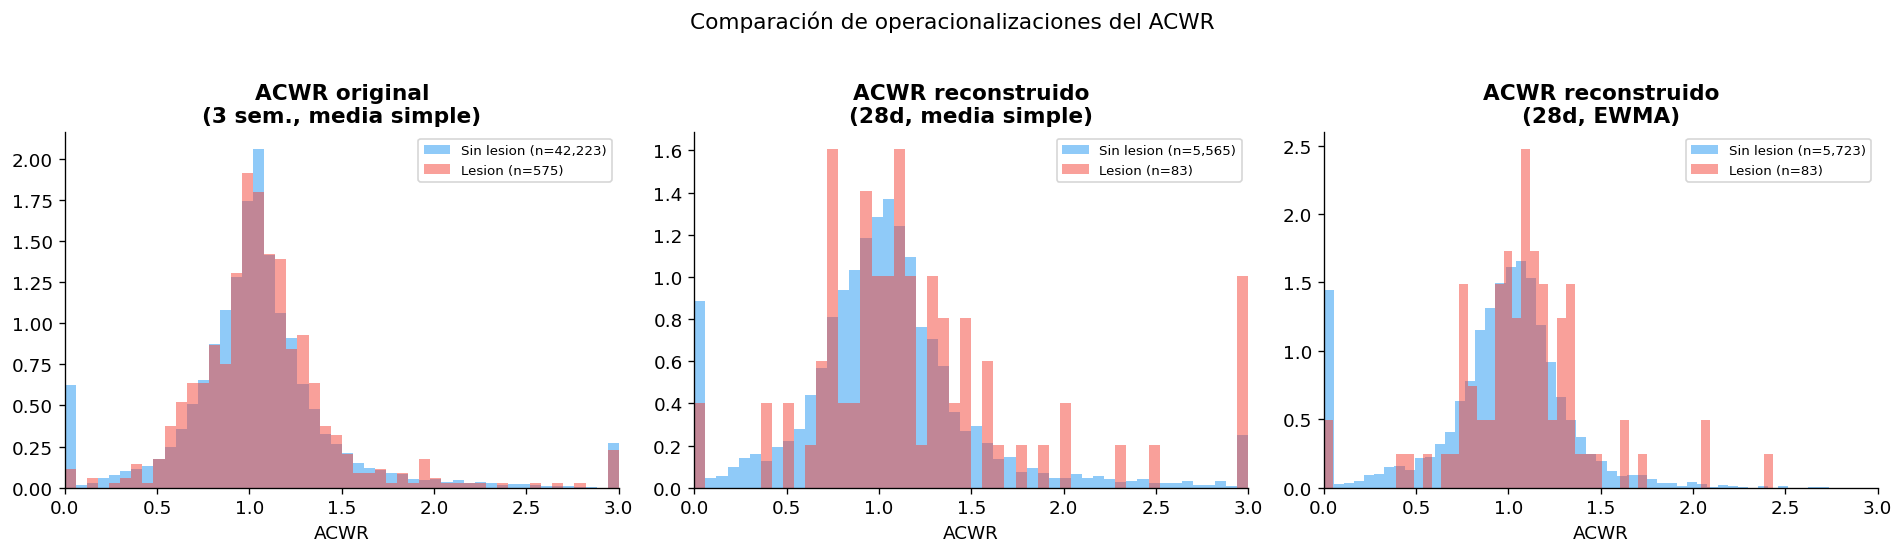

In [ ]:
# Gráfico 15: Comparación de las tres operacionalizaciones del ACWR
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: ACWR original (3 semanas, media simple) — del Bloque 1
for val, label, color in [(0, 'Sin lesion', '#2196F3'), (1, 'Lesion', '#F44336')]:
    subset = df_weekly[df_weekly['injury'] == val]['ACWR'].dropna()
    axes[0].hist(subset, bins=50, alpha=0.5, color=color,
                 label=f'{label} (n={len(subset):,})', density=True)
axes[0].set_title('ACWR original\n(3 sem., media simple)', fontweight='bold')
axes[0].set_xlabel('ACWR')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 3)

# Panel 2: ACWR reconstruido (28d, media simple)
for val, label, color in [(0, 'Sin lesion', '#2196F3'), (1, 'Lesion', '#F44336')]:
    subset = df_weekly_robust[df_weekly_robust['injury'] == val]['ACWR_28d_sma'].dropna()
    axes[1].hist(subset, bins=50, alpha=0.5, color=color,
                 label=f'{label} (n={len(subset):,})', density=True)
axes[1].set_title('ACWR reconstruido\n(28d, media simple)', fontweight='bold')
axes[1].set_xlabel('ACWR')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 3)

# Panel 3: ACWR reconstruido (28d, EWMA)
for val, label, color in [(0, 'Sin lesion', '#2196F3'), (1, 'Lesion', '#F44336')]:
    subset = df_weekly_robust[df_weekly_robust['injury'] == val]['ACWR_28d_ewma'].dropna()
    axes[2].hist(subset, bins=50, alpha=0.5, color=color,
                 label=f'{label} (n={len(subset):,})', density=True)
axes[2].set_title('ACWR reconstruido\n(28d, EWMA)', fontweight='bold')
axes[2].set_xlabel('ACWR')
axes[2].legend(fontsize=8)
axes[2].set_xlim(0, 3)

plt.suptitle('Comparación de operacionalizaciones del ACWR', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf15_acwr_comparison.png'), bbox_inches='tight')
plt.show()

### 6.4 Reentrenamiento de modelos con variables reconstruidas

In [30]:
# Selección de features del pipeline reconstruido
ROBUST_FEATURES = [
    'acute_km_7d', 'km_z_high_7d', 'sessions_7d', 'rest_days_7d',
    'recovery_7d', 'success_7d', 'exertion_7d', 'strength_7d',
    'ACWR_28d_sma', 'ACWR_28d_ewma', 'ACWR_exertion_28d',
    'monotony_7d', 'strain_7d',
    'km_change_7d', 'recovery_trend_7d', 'exertion_trend_7d',
]

# Imputación de NaN (mismo criterio: mediana por atleta + fallback global)
for feat in ROBUST_FEATURES:
    if df_weekly_robust[feat].isna().sum() > 0:
        df_weekly_robust[feat] = df_weekly_robust.groupby('Athlete ID')[feat].transform(
            lambda x: x.fillna(x.median())
        )
        df_weekly_robust[feat] = df_weekly_robust[feat].fillna(df_weekly_robust[feat].median())

nan_count = df_weekly_robust[ROBUST_FEATURES].isnull().sum().sum()
print(f"NaN residuales: {nan_count}")

# Split temporal 70/30 (mismo criterio que pipeline original)
SPLIT_DATE_R = df_weekly_robust['Date'].quantile(0.70)
train_r = df_weekly_robust[df_weekly_robust['Date'] <= SPLIT_DATE_R]
test_r  = df_weekly_robust[df_weekly_robust['Date'] > SPLIT_DATE_R]

X_train_r = train_r[ROBUST_FEATURES].copy()
X_test_r  = test_r[ROBUST_FEATURES].copy()
y_train_r = train_r['injury'].copy()
y_test_r  = test_r['injury'].copy()

scaler_r = StandardScaler()
X_train_r_sc = pd.DataFrame(scaler_r.fit_transform(X_train_r),
                             columns=ROBUST_FEATURES, index=X_train_r.index)
X_test_r_sc  = pd.DataFrame(scaler_r.transform(X_test_r),
                             columns=ROBUST_FEATURES, index=X_test_r.index)

SPW_R = (y_train_r == 0).sum() / max((y_train_r == 1).sum(), 1)

print(f"Split temporal (cutoff={SPLIT_DATE_R:.0f})")
print(f"  Train: {len(X_train_r):,} obs | lesiones: {y_train_r.sum()} ({y_train_r.mean()*100:.2f}%)")
print(f"  Test:  {len(X_test_r):,} obs  | lesiones: {y_test_r.sum()} ({y_test_r.mean()*100:.2f}%)")
print(f"  scale_pos_weight: {SPW_R:.1f}")
print(f"  Features: {len(ROBUST_FEATURES)}")

NaN residuales: 0
Split temporal (cutoff=1792)
  Train: 4,064 obs | lesiones: 45 (1.11%)
  Test:  1,742 obs  | lesiones: 38 (2.18%)
  scale_pos_weight: 89.3
  Features: 16


In [31]:
# Entrenamiento de los tres modelos — pipeline reconstruido
models_r = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=20,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=SPW_R, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    ),
}

results_r = {}
for name, model in models_r.items():
    model.fit(X_train_r_sc, y_train_r)
    y_pred  = model.predict(X_test_r_sc)
    y_proba = model.predict_proba(X_test_r_sc)[:, 1]
    
    results_r[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'roc_auc':   roc_auc_score(y_test_r, y_proba),
        'f1':        f1_score(y_test_r, y_pred),
        'precision': precision_score(y_test_r, y_pred),
        'recall':    recall_score(y_test_r, y_pred),
        'avg_prec':  average_precision_score(y_test_r, y_proba),
    }
    print(f"✓ {name:25s}  ROC-AUC={results_r[name]['roc_auc']:.4f}  "
          f"F1={results_r[name]['f1']:.4f}  Recall={results_r[name]['recall']:.4f}")

✓ Logistic Regression        ROC-AUC=0.5919  F1=0.0580  Recall=0.6053
✓ Random Forest              ROC-AUC=0.5028  F1=0.0000  Recall=0.0000
✓ XGBoost                    ROC-AUC=0.5463  F1=0.0000  Recall=0.0000


### 6.5 Comparativa: pipeline original vs reconstruido

In [ ]:
# Tabla comparativa lado a lado
print("-" * 85)
print("COMPARATIVA DE RENDIMIENTO: PIPELINE ORIGINAL vs RECONSTRUIDO (28d EWMA)")
print("-" * 85)
print(f"{'Modelo':<25s} {'ROC-AUC orig':>13s} {'ROC-AUC 28d':>13s} {'Δ':>8s} │ "
      f"{'Recall orig':>12s} {'Recall 28d':>11s}")
print("-" * 85)

for name in results.keys():
    auc_o = results[name]['roc_auc']
    auc_r = results_r[name]['roc_auc']
    rec_o = results[name]['recall']
    rec_r = results_r[name]['recall']
    delta = auc_r - auc_o
    print(f"{name:<25s} {auc_o:>13.4f} {auc_r:>13.4f} {delta:>+8.4f} │ "
          f"{rec_o:>12.4f} {rec_r:>11.4f}")

print("=" * 85)

# Tabla completa del pipeline reconstruido
metrics_r_df = pd.DataFrame({
    name: {
        'ROC-AUC': r['roc_auc'],
        'Avg Precision': r['avg_prec'],
        'F1': r['f1'],
        'Precision': r['precision'],
        'Recall': r['recall'],
    }
    for name, r in results_r.items()
}).T.round(4)

print("\nDetalle pipeline reconstruido (28d EWMA):")
print(metrics_r_df.to_string())

COMPARATIVA DE RENDIMIENTO: PIPELINE ORIGINAL vs RECONSTRUIDO (28d EWMA)
Modelo                     ROC-AUC orig   ROC-AUC 28d        Δ │  Recall orig  Recall 28d
-------------------------------------------------------------------------------------
Logistic Regression              0.6015        0.5919  -0.0096 │       0.7345      0.6053
Random Forest                    0.5943        0.5028  -0.0915 │       0.0885      0.0000
XGBoost                          0.5545        0.5463  -0.0081 │       0.0708      0.0000

Detalle pipeline reconstruido (28d EWMA):
                     ROC-AUC  Avg Precision     F1  Precision  Recall
Logistic Regression   0.5919         0.0275  0.058     0.0305  0.6053
Random Forest         0.5028         0.0219  0.000     0.0000  0.0000
XGBoost               0.5463         0.0253  0.000     0.0000  0.0000


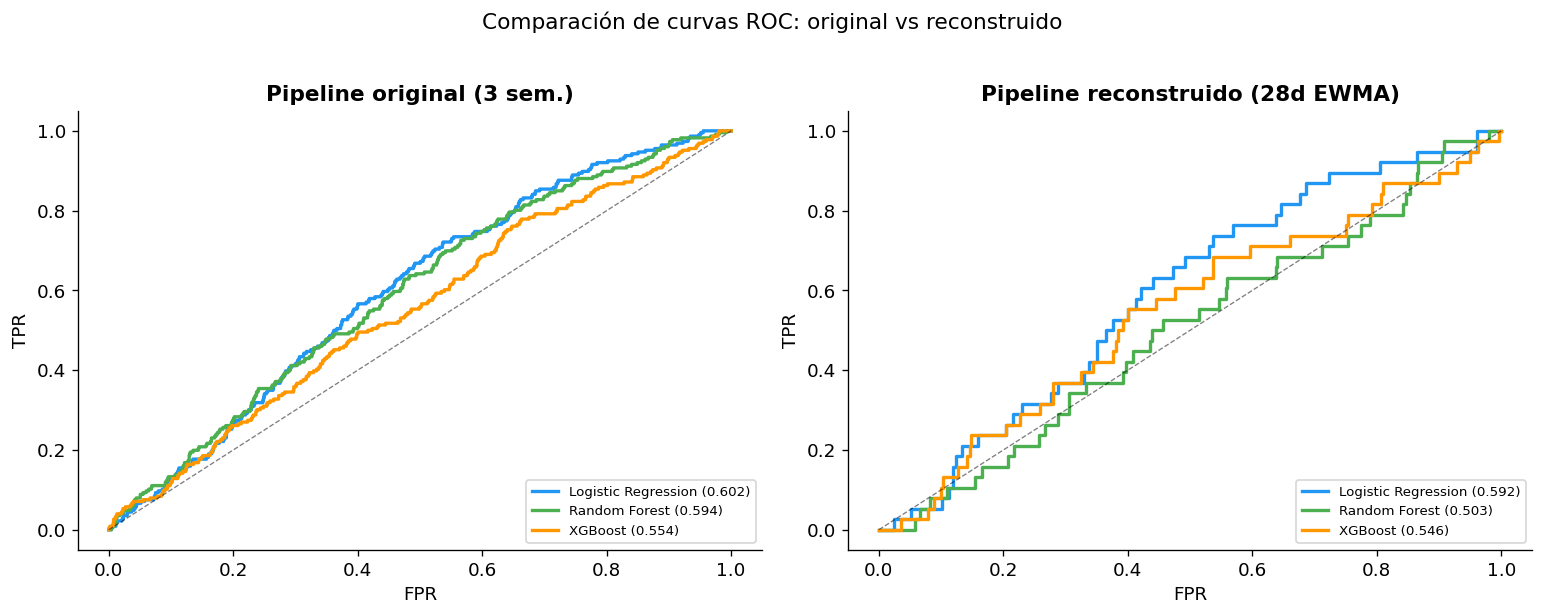

In [ ]:
# Gráfico 16: Curvas ROC comparativas — original vs reconstruido
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = {'Logistic Regression': '#2196F3', 'Random Forest': '#4CAF50', 'XGBoost': '#FF9800'}

# Panel izquierdo: pipeline original
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax1.plot(fpr, tpr, color=colors[name], linewidth=2,
             label=f"{name} ({r['roc_auc']:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
ax1.set_title('Pipeline original (3 sem.)', fontweight='bold')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')
ax1.legend(loc='lower right', fontsize=8)

# Panel derecho: pipeline reconstruido
for name, r in results_r.items():
    fpr, tpr, _ = roc_curve(y_test_r, r['y_proba'])
    ax2.plot(fpr, tpr, color=colors[name], linewidth=2,
             label=f"{name} ({r['roc_auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
ax2.set_title('Pipeline reconstruido (28d EWMA)', fontweight='bold')
ax2.set_xlabel('FPR')
ax2.set_ylabel('TPR')
ax2.legend(loc='lower right', fontsize=8)

plt.suptitle('Comparación de curvas ROC: original vs reconstruido', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf16_roc_comparison.png'), bbox_inches='tight')
plt.show()

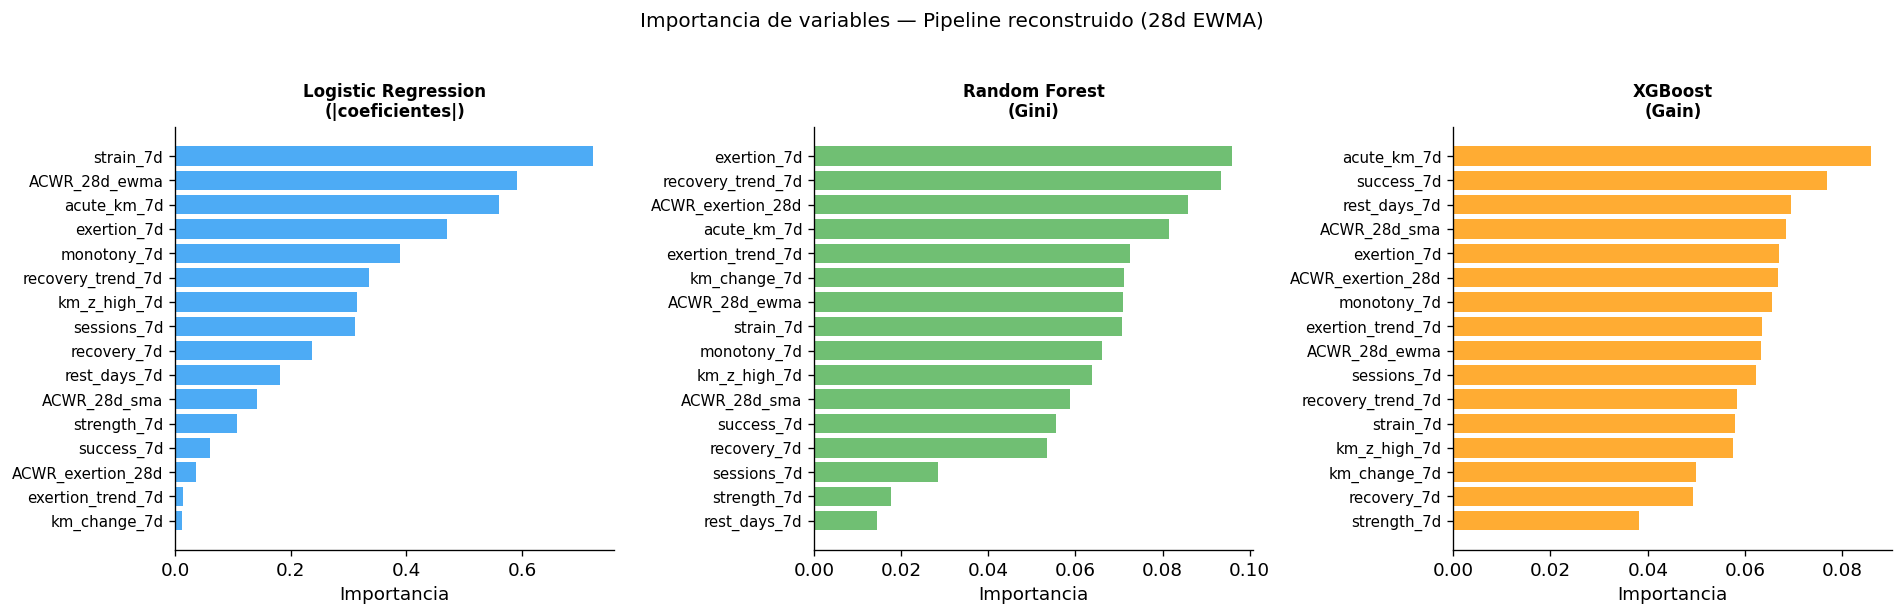

In [ ]:
# Gráfico 17: Importancia de variables — pipeline reconstruido
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

imp_data = [
    (pd.Series(np.abs(results_r['Logistic Regression']['model'].coef_[0]),
               index=ROBUST_FEATURES).sort_values(ascending=False),
     'Logistic Regression\n(|coeficientes|)', '#2196F3'),
    (pd.Series(results_r['Random Forest']['model'].feature_importances_,
               index=ROBUST_FEATURES).sort_values(ascending=False),
     'Random Forest\n(Gini)', '#4CAF50'),
    (pd.Series(results_r['XGBoost']['model'].feature_importances_,
               index=ROBUST_FEATURES).sort_values(ascending=False),
     'XGBoost\n(Gain)', '#FF9800'),
]

for ax, (imp, title, color) in zip(axes, imp_data):
    imp_top = imp.sort_values(ascending=True)  # Todas las features (son 16)
    ax.barh(range(len(imp_top)), imp_top.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(imp_top)))
    ax.set_yticklabels(imp_top.index, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Importancia')

plt.suptitle('Importancia de variables — Pipeline reconstruido (28d EWMA)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graf17_feature_importance_robust.png'), bbox_inches='tight')
plt.show()

### 6.6 Resumen e interpretación del análisis de robustez

El análisis de robustez arroja dos hallazgos principales que merecen una lectura conjunta:

**1. El ACWR con ventana de 28 días y EWMA separa mejor entre clases a nivel descriptivo.**
La diferencia relativa del ACWR entre semanas con y sin lesión pasa del +3,8% en el pipeline
original (3 semanas, media simple) al +15,6% en el reconstruido (28 días, EWMA). Esto indica
que la operacionalización recomendada por la literatura captura mejor la variación de carga
asociada a las lesiones. La media sin lesión baja a 0,94 (frente a 1,05 en el original),
lo que sugiere que la EWMA suaviza la señal crónica y hace más visible el contraste con
los picos agudos.

**2. Sin embargo, los modelos predictivos no mejoran — de hecho empeoran ligeramente.**
La Regresión Logística pasa de ROC-AUC 0,602 a 0,592 (Δ = −0,010), y Random Forest y
XGBoost caen de forma más pronunciada (0,503 y 0,546 respectivamente). RF y XGBoost no
logran detectar ninguna lesión (recall = 0).

**¿Por qué una mejor métrica descriptiva no se traduce en mejores predicciones?**

La explicación principal es la **reducción drástica del tamaño muestral**. El pipeline
reconstruido trabaja con 5.806 observaciones y solo 83 lesiones (38 en test), frente a
las 42.798 observaciones y 575 lesiones del pipeline original. Esta reducción se debe a
dos factores: la exigencia de 21-28 días previos para calcular la carga crónica (que
elimina las primeras semanas de cada atleta) y el muestreo cada 7 días para evitar
solapamiento entre observaciones semanales.

Con solo 45 lesiones en entrenamiento, los modelos de ensemble (RF, XGBoost) no disponen
de suficientes ejemplos positivos para aprender patrones no lineales, y colapsan prediciendo
siempre la clase mayoritaria. La Regresión Logística, al ser más parsimoniosa, resiste mejor
esta situación pero aun así pierde rendimiento.

**Implicación metodológica:** Este resultado sugiere que, en el contexto de eventos raros
como las lesiones deportivas, el tamaño muestral puede ser más determinante que la sofisticación
de las métricas de carga. Una operacionalización más fiel a la literatura (28 días, EWMA)
mejora la descripción del fenómeno pero no compensa la pérdida de datos que su cálculo
impone. Un dataset con observaciones diarias que mantuviese la granularidad temporal sin
necesidad de submuestrear podría combinar ambas ventajas.
